# Exploratory Data Analysis and Machine Learning Problem Selection

<p align="center">
  <img src="../images/meme.png" width="450">
</p>


## Machine Learning Project

**Author:** Makarena Ampuero  

**Course:** Data Science  

**June 2026**


## Objective

Perform exploratory data analysis (EDA) on four different datasets to understand their structure, data quality, patterns, and potential Machine Learning applications.

The objective is to evaluate each dataset and identify the most suitable option for developing a supervised Machine Learning model.

The analysis includes:

- Data exploration and cleaning.
- Identification and treatment of missing values.
- Analysis of numerical and categorical variables.
- Data visualization and pattern detection.
- Evaluation of Machine Learning potential.

After comparing the four datasets, one will be selected for model development, optimization, and deployment.

## Import Libraries

The required Python libraries are imported for data manipulation, numerical analysis, and visualization.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset 1: Environmental Compliance Risk

## Dataset Overview

The Environmental Compliance dataset contains information about environmental projects, including compliance performance, project characteristics, documentation status, and historical non-compliance records.

The main objective of this dataset analysis is to evaluate whether these variables can be used to predict the environmental non-compliance risk level of a project.

The target variable for a potential Machine Learning classification model is:

**Target variable:** `non_compliance_risk`

**Problem type:** Supervised Classification

## 1. Dataset Loading

The dataset contains environmental compliance information related to different projects, including regulatory commitments, compliance status, historical non-compliance records, and risk classification.

In [27]:
df = pd.read_csv("../datasets/environmental_compliance.csv")

In [28]:
df.head()

,empresa,tipo_proyecto,region,numero_rca,año_rca,categoria_compromiso,frecuencia_reporte,responsable_area,dias_restantes,historial_incumplimientos,cantidad_documentos,presupuesto_asociado_usd,criticidad,cumplimiento_porcentaje,estado_avance,riesgo_incumplimiento
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Trimestral,Permisos,120,2,21.0,95808,Alta,77,En Proceso,Medio
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semestral,Operacion,285,1,22.0,40997,Baja,90,Completado,Bajo
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semestral,Medio Ambiente,353,3,17.0,88716,Alta,79,En Proceso,Medio
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semestral,Territorio,236,1,5.0,115304,Baja,94,Completado,Bajo
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Mensual,Construccion,115,2,6.0,69180,Media,66,En Proceso,Bajo


### Initial Dataset Preview

The first rows of the dataset show that each record represents an environmental project with information related to project characteristics, regulatory compliance, documentation, and historical performance.

The dataset contains both numerical and categorical variables, which may provide relevant information for predicting environmental non-compliance risk.

The target variable identified for a potential classification model is **non_compliance_risk**.

## 2. Initial Exploration

An initial exploration is performed to understand the dataset structure, including dimensions, available variables, data types, and general characteristics.

In [29]:
df.shape

(3000, 16)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   empresa                    3000 non-null   str    
 1   tipo_proyecto              3000 non-null   str    
 2   region                     3000 non-null   str    
 3   numero_rca                 3000 non-null   str    
 4   año_rca                    3000 non-null   int64  
 5   categoria_compromiso       3000 non-null   str    
 6   frecuencia_reporte         3000 non-null   str    
 7   responsable_area           2920 non-null   str    
 8   dias_restantes             3000 non-null   int64  
 9   historial_incumplimientos  3000 non-null   int64  
 10  cantidad_documentos        2920 non-null   float64
 11  presupuesto_asociado_usd   3000 non-null   int64  
 12  criticidad                 3000 non-null   str    
 13  cumplimiento_porcentaje    3000 non-null   int64  
 14  est

### Dataset Structure Analysis

The environmental compliance dataset contains **3,000 records and 16 variables** related to environmental project management, regulatory monitoring, and compliance performance.

The dataset includes different types of information:

**Categorical variables (object): 10 columns**

- company
- project_type
- region
- rca_number
- commitment_category
- report_frequency
- responsible_area
- criticality
- progress_status
- non_compliance_risk

**Numerical variables: 6 columns**

- rca_year
- remaining_days
- previous_non_compliance
- document_quantity
- associated_budget_usd
- compliance_percentage


During the initial inspection, missing values were identified in two variables:

- **responsible_area:** 80 missing records.
- **document_quantity:** 80 missing records.

These missing values represent approximately **2.7% of the dataset**, indicating a low proportion of incomplete information.

The appropriate treatment strategy will be evaluated during the data cleaning stage before developing predictive models.

The variable **non_compliance_risk** is identified as the target variable, allowing this dataset to be formulated as a **supervised classification problem**.

### Descriptive Statistics

Descriptive statistics are calculated to analyze the central tendency, dispersion, and range of numerical variables.

In [31]:
df.describe()

,año_rca,dias_restantes,historial_incumplimientos,cantidad_documentos,presupuesto_asociado_usd,cumplimiento_porcentaje
count,3000.000000,3000.000000,3000.000000,2920.000000,3000.000000,3000.000000
mean,2017.464333,183.766333,1.207000,21.137671,75064.882667,71.514333
std,4.616763,105.176416,1.080065,18.489987,25094.708049,20.271460
min,2010.000000,5.000000,0.000000,1.000000,-15191.000000,0.000000
25%,2013.000000,90.000000,0.000000,10.000000,58100.250000,63.000000
50%,2017.000000,181.500000,1.000000,20.000000,75012.000000,75.000000
75%,2021.250000,278.250000,2.000000,29.000000,91639.500000,87.000000
max,2025.000000,364.000000,7.000000,180.000000,159727.000000,100.000000


The descriptive analysis of numerical variables provides an overview of data distribution, ranges, and potential data quality issues.

Main observations:

- **rca_year:**  
Environmental permits included in the dataset range from **2010 to 2025**.  
The average year is approximately **2017**, indicating that the dataset contains projects with different regulatory ages.

- **remaining_days:**  
Projects present between **5 and 364 remaining days** associated with environmental commitment tracking.  
The average value is approximately **184 days**, showing variability in compliance deadlines.

- **previous_non_compliance:**  
Projects have an average of approximately **1.2 previous non-compliance events**.  
Most projects present a low historical non-compliance record, although some cases contain higher values that may represent projects with greater regulatory risk.

- **document_quantity:**  
Projects contain an average of approximately **21 environmental management documents**.  
The presence of higher values may be associated with larger or more complex projects requiring additional documentation.

- **associated_budget_usd:**  
The average associated budget is approximately **75,000 USD**.  
A negative minimum value was detected, which represents a data inconsistency because environmental project budgets cannot have negative values.

- **compliance_percentage:**  
The average environmental compliance percentage is approximately **71.5%**.  
Values range between **0% and 100%**, which represents the expected range for this variable.


Overall, the dataset contains numerical variables with different scales, realistic variability, and some inconsistencies that need to be addressed during the data cleaning stage.

These findings indicate the importance of applying data cleaning, outlier analysis, and feature scaling before developing Machine Learning models.

### Missing Values Detection

Missing values are identified to evaluate data quality and define appropriate cleaning strategies.

In [32]:
missing_values = (df.isnull().sum())

missing_values

empresa                       0
tipo_proyecto                 0
region                        0
numero_rca                    0
año_rca                       0
categoria_compromiso          0
frecuencia_reporte            0
responsable_area             80
dias_restantes                0
historial_incumplimientos     0
cantidad_documentos          80
presupuesto_asociado_usd      0
criticidad                    0
cumplimiento_porcentaje       0
estado_avance                 0
riesgo_incumplimiento         0
dtype: int64

In [33]:
# Missing values percentage

missing_percentage = (
    df.isnull().sum()
    / len(df)
) * 100


missing_percentage[
    missing_percentage > 0
]

responsable_area       2.666667
cantidad_documentos    2.666667
dtype: float64

The missing values analysis identified incomplete information in two variables:

- **responsible_area:** 80 missing records.
- **document_quantity:** 80 missing records.

Both variables contain approximately **2.7% missing values**, representing a small proportion of the complete dataset.

Since the percentage of missing information is low, these variables will be preserved and appropriate imputation strategies will be applied during the data cleaning process.

Possible treatments:

- **responsible_area:** categorical variable that can be completed using the most frequent category or an "Unknown" category.
- **document_quantity:** numerical variable that can be completed using a statistical measure such as the median to reduce the effect of extreme values.

Removing these columns is not recommended because they may contain useful information for predicting environmental non-compliance risk.

## 3. Data Cleaning

A copy of the original dataset is created before applying cleaning transformations.

Missing values are handled according to the type of variable:
- Categorical missing values are replaced with "Unknown".
- Numerical missing values are replaced using the median value to preserve the distribution and reduce the influence of extreme values.

In [34]:
# Load Environmental Compliance dataset

environmental_compliance = pd.read_csv(
    "../datasets/environmental_compliance.csv"
)

environmental_compliance.head()

,empresa,tipo_proyecto,region,numero_rca,año_rca,categoria_compromiso,frecuencia_reporte,responsable_area,dias_restantes,historial_incumplimientos,cantidad_documentos,presupuesto_asociado_usd,criticidad,cumplimiento_porcentaje,estado_avance,riesgo_incumplimiento
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Trimestral,Permisos,120,2,21.0,95808,Alta,77,En Proceso,Medio
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semestral,Operacion,285,1,22.0,40997,Baja,90,Completado,Bajo
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semestral,Medio Ambiente,353,3,17.0,88716,Alta,79,En Proceso,Medio
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semestral,Territorio,236,1,5.0,115304,Baja,94,Completado,Bajo
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Mensual,Construccion,115,2,6.0,69180,Media,66,En Proceso,Bajo


### Data Consistency Check

In [35]:
# Identify projects with negative associated budget values

environmental_compliance[
    environmental_compliance["presupuesto_asociado_usd"] < 0
]

,empresa,tipo_proyecto,region,numero_rca,año_rca,categoria_compromiso,frecuencia_reporte,responsable_area,dias_restantes,historial_incumplimientos,cantidad_documentos,presupuesto_asociado_usd,criticidad,cumplimiento_porcentaje,estado_avance,riesgo_incumplimiento
200,Transelec,Linea de Transmision,Atacama,RCA-7837,2014,Emisiones Atmosfericas,Mensual,Construccion,328,0,30.0,-5969,Alta,91,Completado,Medio
424,Transelec,Parque Solar,Coquimbo,RCA-2344,2021,Reforestacion,Mensual,Territorio,113,1,20.0,-3522,Baja,73,En Proceso,Bajo
551,CGE,Linea de Transmision,Biobio,RCA-4182,2011,Flora y Fauna,Mensual,Construccion,242,1,33.0,-5098,Alta,77,En Proceso,Medio
849,CGE,Subestacion,Coquimbo,RCA-1864,2022,Emisiones Atmosfericas,Semestral,Permisos,119,1,12.0,-8073,Media,89,Completado,Bajo
2270,Engie,Linea de Transmision,Coquimbo,RCA-7975,2021,Ruido,Mensual,NaN,23,1,24.0,-91,Alta,10,Pendiente,Alto
2981,AES Andes,Linea de Transmision,Los Lagos,RCA-9258,2022,Flora y Fauna,Mensual,Territorio,283,0,28.0,-15191,Media,82,Completado,Bajo


In [36]:
# Count negative values in associated budget

(
    environmental_compliance[
        "presupuesto_asociado_usd"
    ] < 0
).sum()

np.int64(6)

During the initial exploration, negative values were detected in the variable `presupuesto_asociado_usd`.

A total of 6 records contain negative budget values.

These values were identified as data inconsistencies because an environmental project budget cannot have a value below zero.

Therefore, these records require treatment before developing Machine Learning models.

### Missing Values Treatment

In [37]:
# Identify missing values in each variable

environmental_compliance.isnull().sum()

empresa                       0
tipo_proyecto                 0
region                        0
numero_rca                    0
año_rca                       0
categoria_compromiso          0
frecuencia_reporte            0
responsable_area             80
dias_restantes                0
historial_incumplimientos     0
cantidad_documentos          80
presupuesto_asociado_usd      0
criticidad                    0
cumplimiento_porcentaje       0
estado_avance                 0
riesgo_incumplimiento         0
dtype: int64

In [38]:
# Calculate missing value percentage by variable

missing_percentage = (
    environmental_compliance.isnull().sum()
    / len(environmental_compliance)
) * 100


missing_percentage[
    missing_percentage > 0
]

responsable_area       2.666667
cantidad_documentos    2.666667
dtype: float64

The missing values analysis shows that most variables in the dataset are complete.

Missing values were identified only in two variables:

- `responsable_area`: 80 missing records.
- `cantidad_documentos`: 80 missing records.

Considering that the dataset contains 3,000 records, missing values represent approximately 2.7% of the total data for each affected variable.

This low percentage indicates that the dataset has good overall quality. However, before developing Machine Learning models, missing values need to be handled to avoid errors during training.

Treatment strategy:

- `responsable_area`: Since this is a categorical variable, missing values will be replaced with `"Unknown"` to preserve the records while indicating unavailable information.

- `cantidad_documentos`: Since this is a numerical variable, missing values will be imputed using the median. The median was selected instead of the mean because this variable contains outliers, and the median is more robust to extreme values.

Rows were not removed because the missing percentage is low and the remaining information from each project may still contribute to predicting environmental compliance risk.

In [39]:
# Create a copy of the original dataset

clean_environmental_compliance = (
    environmental_compliance.copy()
)

In [40]:
# Replace missing categorical values with "Unknown"

clean_environmental_compliance[
    "responsable_area"
] = clean_environmental_compliance[
    "responsable_area"
].fillna(
    "Unknown"
)

In [41]:
# Replace missing numerical values using the median

clean_environmental_compliance[
    "cantidad_documentos"
] = clean_environmental_compliance[
    "cantidad_documentos"
].fillna(
    clean_environmental_compliance[
        "cantidad_documentos"
    ].median()
)

In [42]:
# Replace negative budget values with the median budget

budget_median = clean_environmental_compliance.loc[
    clean_environmental_compliance[
        "presupuesto_asociado_usd"
    ] >= 0,
    "presupuesto_asociado_usd"
].median()


clean_environmental_compliance.loc[
    clean_environmental_compliance[
        "presupuesto_asociado_usd"
    ] < 0,
    "presupuesto_asociado_usd"
] = budget_median

### Cleaning Verification

After applying the missing value treatment, the dataset is checked again to confirm that there are no remaining null values.

In [43]:
# Verify remaining missing values

clean_environmental_compliance.isnull().sum()

empresa                      0
tipo_proyecto                0
region                       0
numero_rca                   0
año_rca                      0
categoria_compromiso         0
frecuencia_reporte           0
responsable_area             0
dias_restantes               0
historial_incumplimientos    0
cantidad_documentos          0
presupuesto_asociado_usd     0
criticidad                   0
cumplimiento_porcentaje      0
estado_avance                0
riesgo_incumplimiento        0
dtype: int64

In [44]:
# Verify negative budget values after cleaning

(
    clean_environmental_compliance[
        "presupuesto_asociado_usd"
    ] < 0
).sum()

np.int64(0)

### Initial Data Cleaning Results

After applying the cleaning process:

- No missing values remain in the dataset.
- Numerical inconsistencies were identified and corrected.
- All original records were preserved because missing values and inconsistencies represented a small percentage of the dataset.
- Categorical missing values were replaced with an `"Unknown"` category to retain information about unavailable data.
- Numerical missing values and inconsistent values were treated using the median due to the presence of outliers.
- The dataset is now prepared for further preprocessing steps and predictive modeling.

In [45]:
# Translate column names to English

clean_environmental_compliance = (
    clean_environmental_compliance.rename(
        columns={
            "empresa": "company",
            "tipo_proyecto": "project_type",
            "region": "region",
            "numero_rca": "rca_number",
            "año_rca": "rca_year",
            "categoria_compromiso": "commitment_category",
            "frecuencia_reporte": "report_frequency",
            "responsable_area": "responsible_area",
            "dias_restantes": "remaining_days",
            "historial_incumplimientos": "previous_non_compliance",
            "cantidad_documentos": "document_quantity",
            "presupuesto_asociado_usd": "associated_budget_usd",
            "criticidad": "criticality",
            "cumplimiento_porcentaje": "compliance_percentage",
            "estado_avance": "progress_status",
            "riesgo_incumplimiento": "non_compliance_risk"
        }
    )
)

In [46]:
# Translate categorical values

clean_environmental_compliance.replace(
    {
        "Bajo": "Low",
        "Medio": "Medium",
        "Alto": "High",

        "Alta": "High",
        "Media": "Medium",
        "Baja": "Low",

        "En Proceso": "In Progress",
        "Completado": "Completed",
        "Pendiente": "Pending",

        "Mensual": "Monthly",
        "Trimestral": "Quarterly",
        "Semestral": "Semiannual"
    },
    inplace=True
)

,company,project_type,region,rca_number,rca_year,commitment_category,report_frequency,responsible_area,remaining_days,previous_non_compliance,document_quantity,associated_budget_usd,criticality,compliance_percentage,progress_status,non_compliance_risk
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Quarterly,Permisos,120,2,21.0,95808,High,77,In Progress,Medium
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semiannual,Operacion,285,1,22.0,40997,Low,90,Completed,Low
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semiannual,Medio Ambiente,353,3,17.0,88716,High,79,In Progress,Medium
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semiannual,Territorio,236,1,5.0,115304,Low,94,Completed,Low
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Monthly,Construccion,115,2,6.0,69180,Medium,66,In Progress,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Enel,Linea de Transmision,Coquimbo,RCA-1949,2011,Calidad de Aguas,Anual,Territorio,134,2,25.0,83048,High,83,Completed,Medium
2996,Engie,Linea de Transmision,Metropolitana,RCA-4587,2012,Calidad de Aguas,Quarterly,Territorio,26,0,25.0,88713,High,13,Pending,High
2997,Engie,Linea de Transmision,Metropolitana,RCA-2111,2016,Flora y Fauna,Semiannual,Territorio,139,1,1.0,53470,High,88,Completed,Medium
2998,Engie,Linea de Transmision,Antofagasta,RCA-9367,2018,Ruido,Monthly,Permisos,24,3,22.0,70390,High,41,In Progress,High


In [47]:
clean_environmental_compliance.head()

,company,project_type,region,rca_number,rca_year,commitment_category,report_frequency,responsible_area,remaining_days,previous_non_compliance,document_quantity,associated_budget_usd,criticality,compliance_percentage,progress_status,non_compliance_risk
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Quarterly,Permisos,120,2,21.0,95808,High,77,In Progress,Medium
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semiannual,Operacion,285,1,22.0,40997,Low,90,Completed,Low
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semiannual,Medio Ambiente,353,3,17.0,88716,High,79,In Progress,Medium
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semiannual,Territorio,236,1,5.0,115304,Low,94,Completed,Low
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Monthly,Construccion,115,2,6.0,69180,Medium,66,In Progress,Low


## 4. Exploratory Data Analysis (EDA)

### Target Variable Analysis

- Risk Distribution

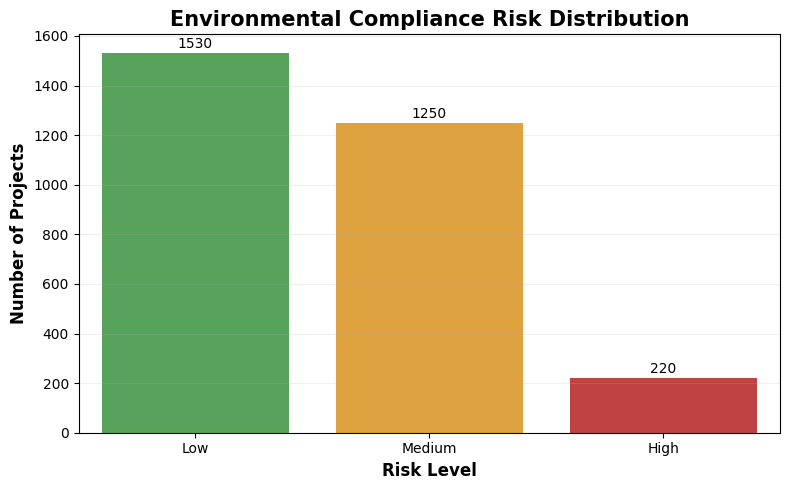

In [25]:
# Environmental compliance risk distribution

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",      
    "Medium": "#F9A825",   
    "High": "#D32F2F"       
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    data=clean_environmental_compliance,
    x="non_compliance_risk",
    hue="non_compliance_risk",
    order=risk_order,
    palette=risk_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Environmental Compliance Risk Distribution",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Projects",
    fontsize=12,
    fontweight="bold"
)


# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10,
        padding=1.5
    )


ax.grid(
    axis="y",
    alpha=0.2
)


plt.tight_layout()

plt.show()

The distribution of environmental non-compliance risk shows that most projects are classified as **Low** or **Medium Risk**, while a smaller proportion belongs to the **High Risk** category.

This indicates that although the majority of projects maintain acceptable compliance conditions, there is a specific group of projects with higher probability of environmental non-compliance that requires closer monitoring.

The presence of three clearly defined risk categories supports the development of a **supervised classification model**, where the objective is to predict the environmental risk level of a project based on its characteristics and compliance indicators.

### Numerical Variables Analysis

- Compliance Percentage Distribution

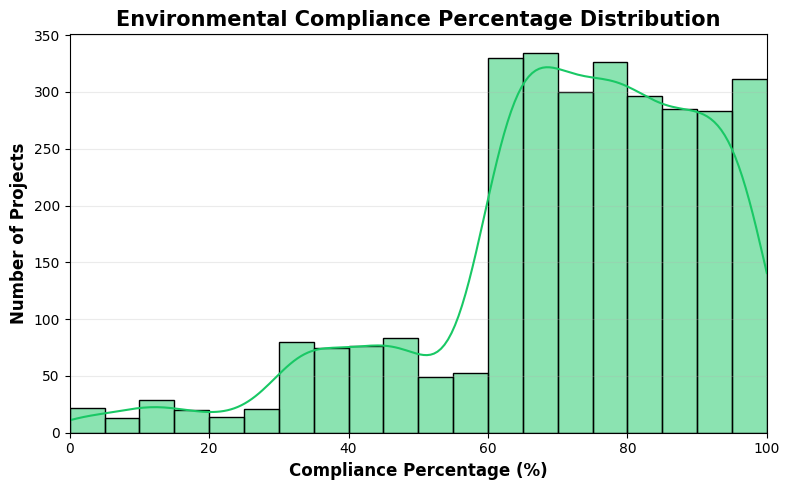

In [ ]:
# Environmental compliance percentage distribution

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.histplot(
    data=clean_environmental_compliance,
    x="compliance_percentage",
    bins=20,
    kde=True,
    color="#19C865",
    ax=ax
)


ax.set_title(
    "Environmental Compliance Percentage Distribution",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Compliance Percentage (%)",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Projects",
    fontsize=12,
    fontweight="bold"
)


ax.set_xlim(
    0,
    100
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The distribution shows that most environmental projects present compliance percentages above **60%**, with a high concentration of projects reaching medium to high compliance levels.

**Environmental interpretation:**  
This suggests that most projects are actively fulfilling their environmental commitments. However, the presence of projects with lower compliance percentages indicates potential cases that may require additional monitoring, corrective actions, or regulatory follow-up.

**Machine Learning relevance:**  
Compliance percentage represents an important predictive variable because differences in fulfillment levels can help distinguish between **Low, Medium, and High environmental non-compliance risk categories**.

- Compliance by Risk Level

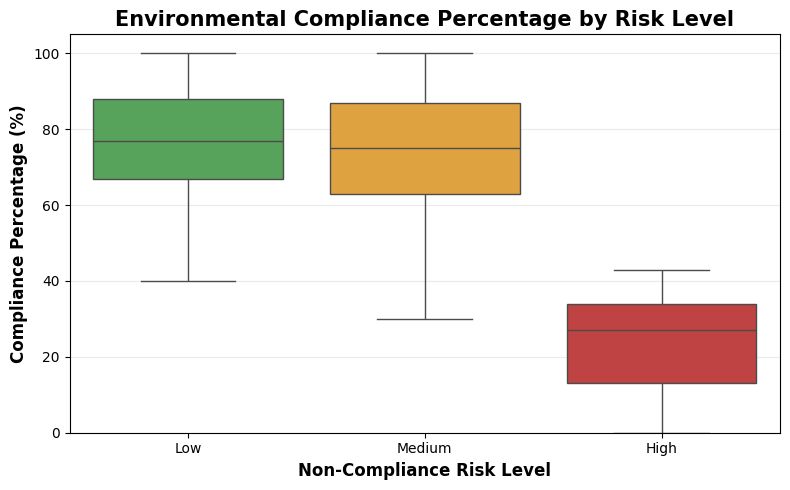

In [ ]:
# Environmental compliance percentage by risk level

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",
    "Medium": "#F9A825",
    "High": "#D32F2F"
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_environmental_compliance,
    x="non_compliance_risk",
    y="compliance_percentage",
    hue="non_compliance_risk",
    order=risk_order,
    palette=risk_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Environmental Compliance Percentage by Risk Level",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Non-Compliance Risk Level",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Compliance Percentage (%)",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylim(
    0,
    105
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The analysis shows a clear relationship between environmental compliance percentage and non-compliance risk classification.

Projects classified as **Low** and **Medium Risk** present higher compliance percentages, while **High Risk** projects show significantly lower compliance levels.

**Environmental interpretation:**  
High-risk projects have a considerably lower median compliance percentage, indicating weaker fulfillment of environmental commitments and a greater need for monitoring, preventive actions, and regulatory control.

The separation between risk categories suggests that compliance performance is strongly associated with environmental risk levels.

**Machine Learning relevance:**  
This variable provides strong predictive information for the classification model, as compliance behavior helps distinguish between different environmental non-compliance risk categories.

- Previous Non-Compliance Records

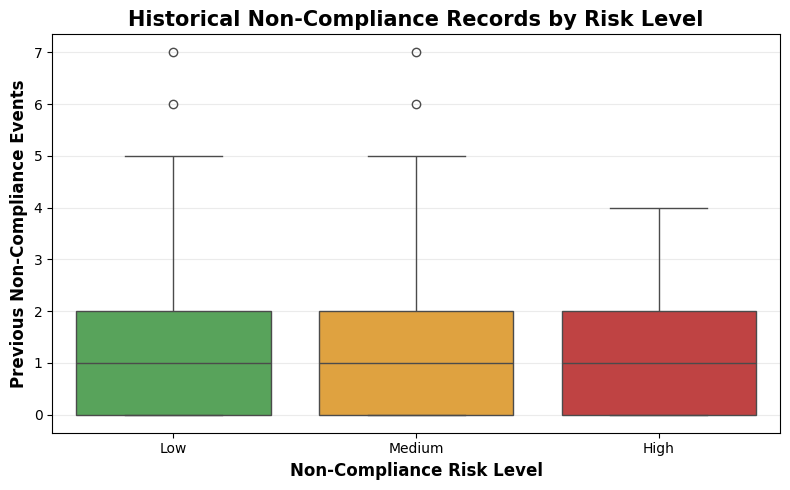

In [ ]:
# Historical environmental non-compliance records by risk level

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",
    "Medium": "#F9A825",
    "High": "#D32F2F"
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_environmental_compliance,
    x="non_compliance_risk",
    y="previous_non_compliance",
    hue="non_compliance_risk",
    order=risk_order,
    palette=risk_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Historical Non-Compliance Records by Risk Level",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Non-Compliance Risk Level",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Previous Non-Compliance Events",
    fontsize=12,
    fontweight="bold"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The distribution of previous environmental non-compliance events is relatively similar across the three risk categories.

Most projects present a low number of historical non-compliance records, although some isolated cases show higher values.

**Environmental interpretation:**  
The presence of outliers indicates that certain projects have experienced repeated compliance issues in the past, which may require additional monitoring and preventive actions.

However, historical non-compliance alone does not completely explain the environmental risk classification and should be analyzed together with other compliance indicators.

**Machine Learning relevance:**  
Previous non-compliance records can provide complementary information to the predictive model, but risk classification is likely influenced by multiple variables such as compliance percentage, project criticality, deadlines, and project characteristics.

### Categorical Variables Analysis

- Criticality and Risk Relationship

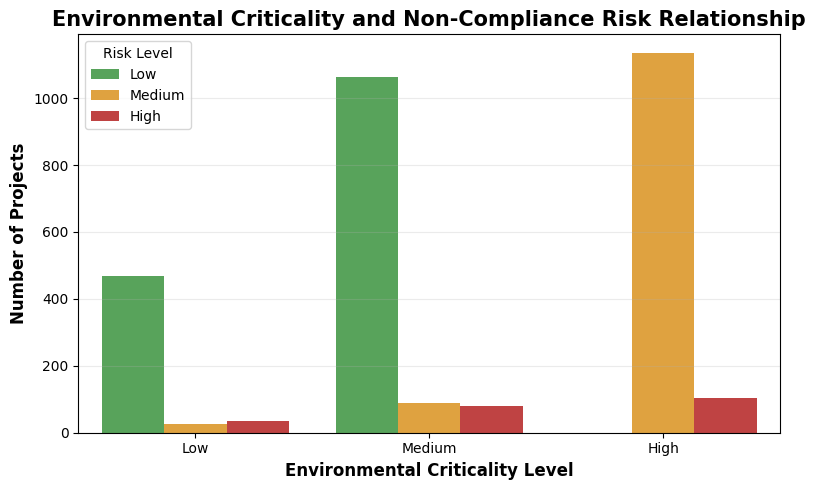

In [ ]:
# Environmental criticality and non-compliance risk relationship

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",
    "Medium": "#F9A825",
    "High": "#D32F2F"
}


criticality_order = [
    "Low",
    "Medium",
    "High"
]


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    data=clean_environmental_compliance,
    x="criticality",
    hue="non_compliance_risk",
    order=criticality_order,
    hue_order=risk_order,
    palette=risk_colors,
    ax=ax
)


ax.set_title(
    "Environmental Criticality and Non-Compliance Risk Relationship",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Environmental Criticality Level",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Projects",
    fontsize=12,
    fontweight="bold"
)


ax.legend(
    title="Risk Level"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The analysis shows a strong relationship between environmental criticality level and non-compliance risk classification.

Projects with **Low** and **Medium Criticality** are mainly associated with **Low Risk**, while projects classified as **High Criticality** present a considerable increase in **Medium and High Risk categories**.

**Environmental interpretation:**  
Higher criticality projects are more likely to require additional environmental supervision due to greater operational complexity, regulatory requirements, or potential environmental impacts.

This suggests that criticality level is an important factor when prioritizing monitoring efforts and preventive compliance strategies.

**Machine Learning relevance:**  
Environmental criticality provides highly relevant predictive information for the classification model.

The clear differences between criticality groups help the model distinguish risk patterns and improve environmental non-compliance prediction.

- Project Type Analysis

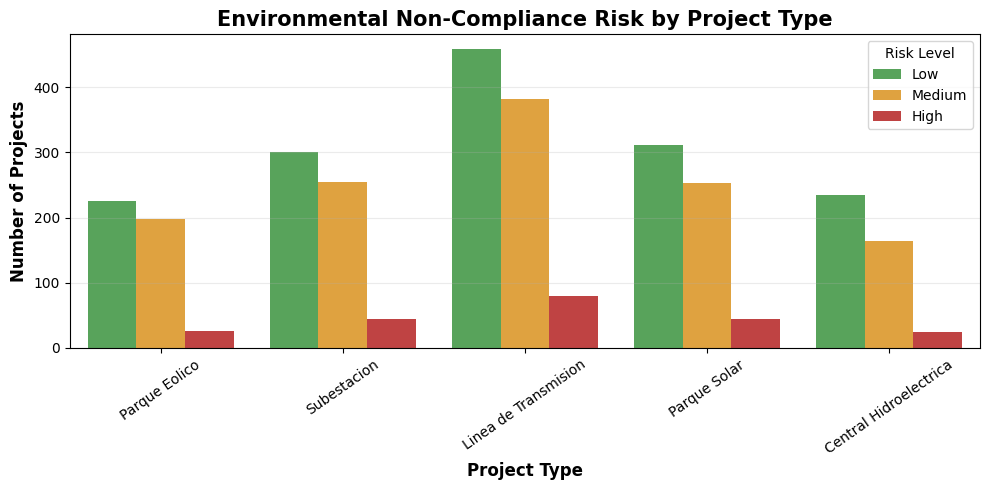

In [ ]:
# Environmental non-compliance risk by project type

risk_order = [
    "Low",
    "Medium",
    "High"
]


risk_colors = {
    "Low": "#4CAF50",
    "Medium": "#F9A825",
    "High": "#D32F2F"
}


fig, ax = plt.subplots(
    figsize=(10, 5)
)


sns.countplot(
    data=clean_environmental_compliance,
    x="project_type",
    hue="non_compliance_risk",
    hue_order=risk_order,
    palette=risk_colors,
    ax=ax
)


ax.set_title(
    "Environmental Non-Compliance Risk by Project Type",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Project Type",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Projects",
    fontsize=12,
    fontweight="bold"
)


ax.tick_params(
    axis="x",
    rotation=35,
    labelsize=10
)


ax.tick_params(
    axis="y",
    labelsize=10
)


ax.legend(
    title="Risk Level"
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()

**Main finding:**  
The analysis shows that environmental non-compliance risk is present across all project types, with different distributions depending on project category.

Transmission Line projects represent the largest group in the dataset and also contain the highest number of Medium and High Risk cases.

**Environmental interpretation:**  
The presence of higher risk cases in certain project types may be related to differences in operational complexity, regulatory requirements, geographical extension, or the number of environmental commitments associated with each project.

Large infrastructure projects, such as transmission lines, often require continuous environmental monitoring due to their interaction with multiple areas and stakeholders.

**Machine Learning relevance:**  
Project type provides contextual information that may help the classification model identify environmental risk patterns.

However, risk prediction should consider multiple variables together, including project criticality, compliance percentage, and historical compliance performance.

### Outlier Analysis

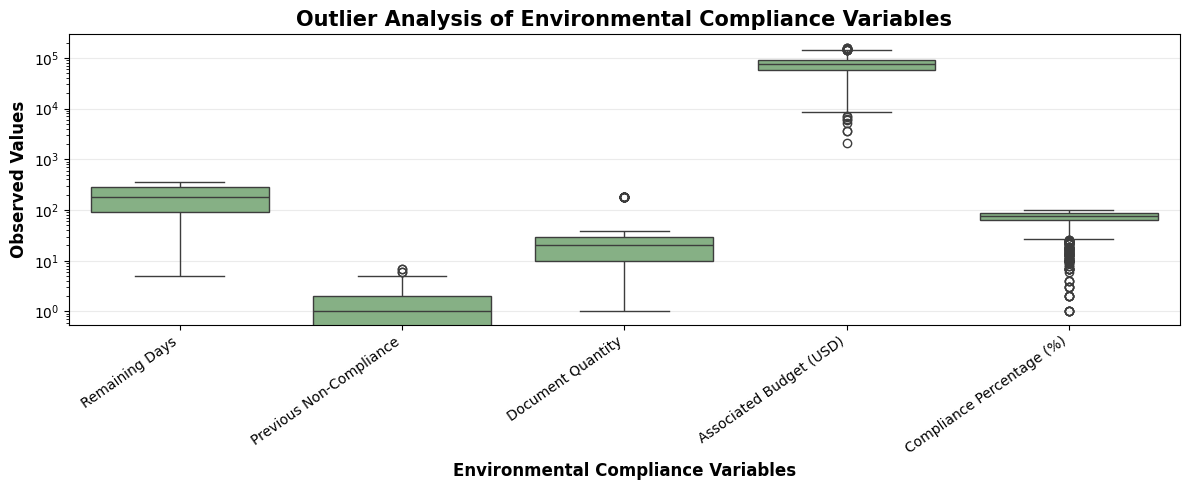

In [ ]:
# Outlier analysis for numerical environmental compliance variables

outlier_variables = [
    "remaining_days",
    "previous_non_compliance",
    "document_quantity",
    "associated_budget_usd",
    "compliance_percentage"
]


variable_labels = [
    "Remaining Days",
    "Previous Non-Compliance",
    "Document Quantity",
    "Associated Budget (USD)",
    "Compliance Percentage (%)"
]


fig, ax = plt.subplots(
    figsize=(12, 5)
)


sns.boxplot(
    data=clean_environmental_compliance[
        outlier_variables
    ],
    color="#7FB77E",
    ax=ax
)


ax.set_title(
    "Outlier Analysis of Environmental Compliance Variables",
    fontsize=15,
    fontweight="bold"
)


ax.set_xlabel(
    "Environmental Compliance Variables",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Observed Values",
    fontsize=12,
    fontweight="bold"
)


ax.set_xticks(
    range(
        len(variable_labels)
    )
)

ax.set_xticklabels(
    variable_labels,
    rotation=35,
    ha="right"
)


ax.tick_params(
    axis="y",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_yscale(
    "log"
)

plt.tight_layout()

plt.show()

**Main finding:**  
The outlier analysis shows variability across several numerical environmental compliance variables. The use of a logarithmic scale allows variables with different magnitudes to be compared more effectively.

**Environmental interpretation:**  
Some variables, especially **Associated Budget (USD)**, present extreme values due to differences in project size, complexity, and environmental management requirements.

Additionally, variations in documents, deadlines, and compliance percentages reflect the diversity of environmental projects included in the dataset.

These values were preserved because they represent realistic project conditions rather than data quality issues.

**Machine Learning relevance:**  
The presence of different value ranges and extreme observations highlights the importance of applying preprocessing techniques before model training.

Numerical scaling methods such as **StandardScaler** will be included in the Machine Learning pipeline to reduce scale differences and improve model performance.

### Correlation Analysis

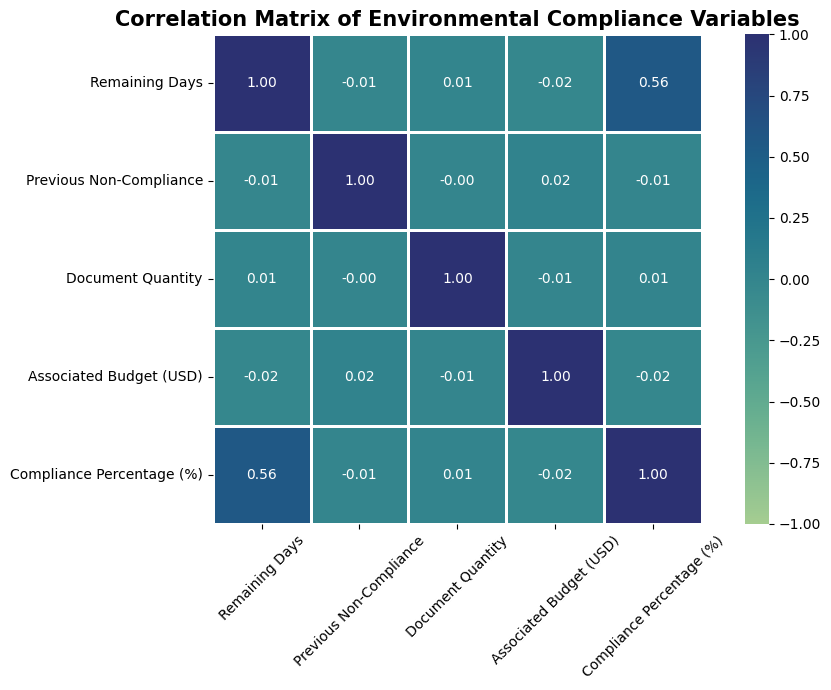

In [ ]:
# Correlation analysis of numerical environmental compliance variables

correlation_variables = [
    "remaining_days",
    "previous_non_compliance",
    "document_quantity",
    "associated_budget_usd",
    "compliance_percentage"
]


correlation_labels = [
    "Remaining Days",
    "Previous Non-Compliance",
    "Document Quantity",
    "Associated Budget (USD)",
    "Compliance Percentage (%)"
]


correlation_matrix = (
    clean_environmental_compliance[
        correlation_variables
    ]
    .corr()
)


# Rename variables only for visualization

correlation_matrix.columns = (
    correlation_labels
)

correlation_matrix.index = (
    correlation_labels
)


fig, ax = plt.subplots(
    figsize=(10, 7)
)


sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="crest",
    linewidths=1,
    linecolor="white",
    square=True,
    vmin=-1,
    vmax=1,
    center=0,
    ax=ax
)

ax.set_title(
    "Correlation Matrix of Environmental Compliance Variables",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=10
)

plt.tight_layout()

plt.show()

**Main finding:**  
The correlation matrix shows that most numerical environmental compliance variables have weak linear relationships, suggesting that each variable provides different information about project behavior.

A moderate positive correlation (**0.56**) was observed between **Remaining Days** and **Compliance Percentage**.

**Environmental interpretation:**  
Projects with more remaining time tend to present higher compliance percentages. This may be related to better planning, earlier follow-up stages, or greater availability of time to complete environmental commitments.

The weak correlations among the remaining variables suggest that environmental compliance risk is influenced by multiple factors rather than a single numerical indicator.

**Machine Learning relevance:**  
The absence of strong correlations between predictors reduces the risk of multicollinearity.

Combining variables related to deadlines, compliance performance, documentation, budget, and historical records allows the model to capture different aspects of environmental risk prediction.

## 5. Dataset Evaluation Summary

The exploratory data analysis showed that the environmental compliance dataset contains suitable characteristics to address a Machine Learning classification problem.

The selected problem is the **prediction of environmental non-compliance risk**, using **non_compliance_risk** as the target variable.

The dataset contains:

- **3,000 environmental project records.**
- Relevant numerical and categorical variables related to environmental management.
- A low percentage of missing values, which were treated during the initial data cleaning process.
- Meaningful relationships between compliance indicators and environmental risk categories.
- Predictive variables associated with compliance performance, project criticality, deadlines, and historical records.

The main challenges identified for the next stages are:

- Encoding categorical variables using appropriate transformation techniques.
- Scaling numerical variables due to different ranges and magnitudes.
- Applying preprocessing pipelines to ensure reproducibility.
- Training and comparing multiple Machine Learning classification algorithms.
- Optimizing model performance through hyperparameter tuning techniques.

# Dataset 2: Air Quality Prediction

## Dataset Overview

The Air Quality dataset contains information about environmental monitoring records, including air pollutant concentrations, atmospheric conditions, and factors associated with air quality variation.

The main objective of this dataset analysis is to evaluate whether these variables can be used to predict the air quality category based on environmental and pollution indicators.

The target variable for a potential Machine Learning classification model is:

**Target variable:** `air_quality`

**Problem type:** Supervised Classification

## 1. Dataset Loading

In [340]:
openaq = pd.read_csv("../datasets/openaq.csv", sep=";")

In [341]:
openaq.head()

,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label
0,HU,Budapest Budatétény,Budapest Budatétény,"47.40605, 19.0099",PM2.5,hungary-nms,µg/m³,7.000000,2023-08-03T22:00:00+10:00,Hungary
1,HU,Budapest Honvéd,Budapest Honvéd,"47.522693, 19.069867",CO,hungary-nms,µg/m³,289.000000,2023-08-10T06:00:00+10:00,Hungary
2,HU,Budapest,HU0045A,"47.4919433594653, 19.08778191",SO2,EEA Hungary,µg/m³,5.496181,2023-08-10T06:00:00+10:00,Hungary
3,HU,Kazincbarcika,Kazincbarcika,"48.247032999999995, 20.61445",PM10,hungary-nms,µg/m³,6.000000,2023-08-09T10:00:00+10:00,Hungary
4,HU,Székesfehérvár,Székesfehérvár,"47.195944, 18.400246",CO,hungary-nms,µg/m³,237.000000,2023-08-09T10:00:00+10:00,Hungary


### Initial Dataset Preview

The first rows of the dataset show air quality monitoring records from different locations.

Each record contains information about geographic location, pollutant type, measurement unit, pollutant concentration value, data source, and update date.

The dataset includes environmental variables that can be analyzed to identify air pollution patterns across different regions and pollutants.

## 2. Initial Exploration

An initial exploration is performed to understand the dataset structure, including dimensions, available variables, data types, and general characteristics.

In [342]:
openaq.shape

(43450, 10)

In [343]:
openaq.info()

<class 'pandas.DataFrame'>
RangeIndex: 43450 entries, 0 to 43449
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Code   43450 non-null  str    
 1   City           26730 non-null  str    
 2   Location       43448 non-null  str    
 3   Coordinates    43231 non-null  str    
 4   Pollutant      43450 non-null  str    
 5   Source Name    43450 non-null  str    
 6   Unit           43450 non-null  str    
 7   Value          43450 non-null  float64
 8   Last Updated   43450 non-null  str    
 9   Country Label  43335 non-null  str    
dtypes: float64(1), str(9)
memory usage: 3.3 MB


### Dataset Structure Analysis

The Air Quality dataset contains **43,450 records and 10 variables** related to atmospheric monitoring and pollutant measurements.

The dataset includes different types of information:

**Categorical variables (object): 9 columns**

- country_code
- city
- location
- coordinates
- pollutant
- source_name
- unit
- last_updated
- country_label


**Numerical variables: 1 column**

- value


During the initial inspection, missing values were identified in four variables:

- **city:** 16,720 missing records.
- **location:** 2 missing records.
- **coordinates:** 219 missing records.
- **country_label:** 115 missing records.

The variable with the highest proportion of missing information is **city**, while the remaining variables present a low number of missing records.

Missing value treatment strategies will be evaluated during the data cleaning stage.

The variable **value** represents pollutant concentration measurements and can be used for environmental analysis and potential air quality prediction tasks.

### Descriptive Statistics

In [344]:
openaq.describe()

,Value
count,4.345000e+04
mean,7.663160e+02
std,3.270961e+04
min,-4.905140e+04
25%,1.600000e+00
50%,1.039900e+01
75%,3.684375e+01
max,3.198676e+06


The descriptive analysis of the numerical variable provides information about the distribution of pollutant concentration measurements.

Main observations:

- **value:**  
The pollutant concentration values present a wide range of measurements, from negative values to extremely high values.

The average concentration value is approximately **766.31**, while the median is around **10.39**, indicating a highly skewed distribution influenced by extreme values.

The maximum value detected is approximately **319,867**, suggesting the presence of potential outliers or measurements that require further validation.

Negative concentration values were also identified, which represent data inconsistencies because pollutant concentrations cannot be below zero.

Overall, the dataset requires data consistency checks, treatment of invalid values, and outlier analysis before being used for Machine Learning models.

### Missing Values Detection

In [345]:
missing_values = (openaq.isnull().sum())

missing_values

Country Code         0
City             16720
Location             2
Coordinates        219
Pollutant            0
Source Name          0
Unit                 0
Value                0
Last Updated         0
Country Label      115
dtype: int64

The missing values analysis identified incomplete information in four variables:

- **city:** 16,720 missing records.
- **location:** 2 missing records.
- **coordinates:** 219 missing records.
- **country_label:** 115 missing records.

The variable with the highest amount of missing information is **city**, representing a considerable proportion of the dataset.

The remaining variables contain only a small number of missing values compared to the total number of records.

Possible treatments:

- **city:** since it is a categorical geographic variable, missing values could be replaced using the location information when available or assigned as "Unknown".
- **location:** due to the very low number of missing records, these observations could be removed or completed using available geographic information.
- **coordinates:** missing values could be completed using city/location information if required for geographic analysis.
- **country_label:** missing values could be inferred from the existing country code.

The treatment strategy will depend on whether geographic variables are considered relevant for the final Machine Learning problem.

## 3. Data Cleaning
A copy of the original dataset is created before applying cleaning transformations.

Data cleaning will focus on:

- Treatment of missing geographic information.
- Detection and correction of invalid pollutant concentration values.
- Verification of dataset consistency before exploratory analysis.

### Data Consistency Check

In [346]:
# Identify negative pollutant concentration values

openaq[
    openaq["Value"] < 0
]

,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label
102,DE,Berlin,DEBE068,"52.513606, 13.418833",NO,EEA Germany,µg/m³,-0.70,2023-08-10T07:00:00+10:00,Germany
297,FR,Haute-Vienne,FR35007,"45.8699934537509, 1.31000419567866",PM10,EEA France,µg/m³,-0.30,2023-08-10T04:00:00+10:00,France
300,FR,Savoie,FR33111,"45.2747219994632, 6.349722",NO,EEA France,µg/m³,-0.40,2023-08-10T07:00:00+10:00,France
308,FR,Indre-et-Loire,FR34028,"47.3946463856954, 0.704872969152508",PM2.5,EEA France,µg/m³,-0.80,2023-08-10T06:00:00+10:00,France
328,FR,Landes,FR31026,"43.8383470414065, -0.810832850175542",SO2,EEA France,µg/m³,-0.20,2023-08-10T07:00:00+10:00,France
...,...,...,...,...,...,...,...,...,...,...
42817,NL,Biddinghuizen,Biddinghuizen-Kuilweg,"52.4232, 5.59338",NO2,Netherlands,µg/m³,-995.00,2023-08-10T09:00:00+10:00,Netherlands
42818,NL,Valthermond,Valthermond-Noorderdiep,"52.8757, 6.93243",PM10,Netherlands,µg/m³,-3.25,2023-08-10T09:00:00+10:00,Netherlands
42821,NL,Amsterdam,Amsterdam-Kantershof (Zuid Oost),"52.3207, 4.9884",NO,Netherlands,µg/m³,-0.20,2023-08-10T09:00:00+10:00,Netherlands
42992,AU,South West Queensland,Hopeland,"-26.863700000000005, 150.5028",PM2.5,Australia - Queensland,µg/m³,-9999.00,2023-06-13T10:00:00+10:00,Australia


In [347]:
# Identify duplicated records

openaq.duplicated().sum()

np.int64(0)

The data consistency check was performed to identify possible issues that could affect the quality of the analysis and future Machine Learning models.

The following aspects were evaluated:

- **Negative pollutant concentration values:**  
  Negative values were identified in the **Value** variable. Since pollutant concentrations cannot have values below zero, these records represent invalid measurements and require correction.

- **Duplicate records:**  
  Duplicate observations were reviewed to prevent repeated measurements from influencing the analysis and generating biased results.

- **Date format consistency:**  
  The **Last Updated** variable was reviewed because it represents temporal information but was initially stored as an object data type.

Identified inconsistencies will be corrected during the cleaning process while preserving as much environmental monitoring information as possible.

In [348]:
# Create a copy of the original dataset for cleaning

clean_openaq = (
    openaq.copy()
)

In [349]:
# Replace invalid negative pollutant values with missing values

clean_openaq.loc[
    clean_openaq["Value"] < 0,
    "Value"
] = np.nan

In [350]:
# Convert date variable to datetime format

clean_openaq["Last Updated"] = (
    pd.to_datetime(
        clean_openaq["Last Updated"],
        errors="coerce"
    )
)

### Missing Values Treatment

In [351]:
clean_openaq.isnull().sum()

Country Code         0
City             16720
Location             2
Coordinates        219
Pollutant            0
Source Name          0
Unit                 0
Value              597
Last Updated         0
Country Label      115
dtype: int64

The missing values analysis identified incomplete information mainly related to geographic variables.

Missing values were treated according to the characteristics of each variable:

- **City:** Missing values were replaced with "Unknown" to preserve monitoring records where city information was unavailable.

- **Location:** Missing values were replaced with "Unknown" because it represents categorical geographic information.

- **Coordinates:** Missing values were replaced with "Unknown" since geographic coordinates are descriptive information and not required for all analyses.

- **Country Label:** Missing values were replaced with "Unknown", preserving the available country code information.

- **Value:** Invalid or missing pollutant concentration measurements were replaced using the median because pollutant values contain extreme observations and the median is less affected by outliers.

Rows were not removed in order to preserve the maximum amount of environmental monitoring information.

In [352]:
# Replace missing categorical values with "Unknown"

categorical_columns = [
    "City",
    "Location",
    "Coordinates",
    "Country Label"
]


for column in categorical_columns:
    clean_openaq[column] = (
        clean_openaq[column]
        .fillna("Unknown")
    )

In [353]:
# Replace missing numerical values using the median

clean_openaq["Value"] = (
    clean_openaq["Value"]
    .fillna(
        clean_openaq["Value"].median()
    )
)

### Cleaning Verification

In [354]:
# Verify missing values after cleaning

clean_openaq.isnull().sum()

Country Code     0
City             0
Location         0
Coordinates      0
Pollutant        0
Source Name      0
Unit             0
Value            0
Last Updated     0
Country Label    0
dtype: int64

### Initial Data Cleaning Results

After applying the initial data cleaning process:

- Missing values were successfully treated according to the characteristics of each variable.
- Geographic variables with missing information were completed using the category **"Unknown"**.
- Invalid negative pollutant concentration values were corrected using a statistical treatment strategy.
- Duplicate records were evaluated and removed when necessary to avoid repeated observations.
- The **Last Updated** variable was converted to datetime format to correctly represent temporal information.
- All original variables were preserved for exploratory analysis.

The dataset is now consistent and prepared for further exploratory data analysis and Machine Learning problem evaluation.

## 4. Feature Engineering

### Target Variable Creation

The original dataset does not contain a predefined classification target variable.

To formulate a supervised Machine Learning problem, a new categorical variable named **air_quality** was created based on pollutant concentration values.

This transformation allows pollutant measurements to be classified into different air quality levels and enables the development of classification models.

In [355]:
# Create air quality classification target variable

def classify_air_quality(value):

    if value <= 12:
        return "Good"

    elif value <= 35:
        return "Moderate"

    else:
        return "Poor"


clean_openaq["air_quality"] = (
    clean_openaq["Value"]
    .apply(classify_air_quality)
)

In [356]:
# Verify target variable creation

clean_openaq[
    "air_quality"
].value_counts()

air_quality
Good        23266
Poor        11113
Moderate     9071
Name: count, dtype: int64

## 5. Exploratory Data Analysis (EDA)

### Target Variable Analysis 

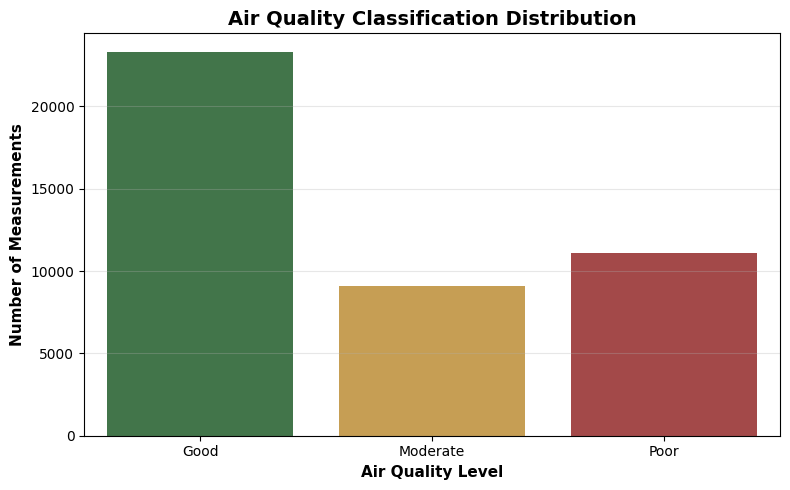

In [357]:
# Air quality classification distribution

air_quality_colors = {
    "Good": "#3A7D44",
    "Moderate": "#D9A441",
    "Poor": "#B23A3A"
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    data=clean_openaq,
    x="air_quality",
    hue="air_quality",
    order=[
        "Good",
        "Moderate",
        "Poor"
    ],
    palette=air_quality_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Air Quality Classification Distribution",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Air Quality Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Measurements",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The distribution of the created air quality classification variable shows that most measurements are classified as **Good Air Quality**, followed by **Poor** and **Moderate Air Quality** categories.

This indicates that although a large proportion of monitoring records present acceptable pollutant concentration levels, a significant number of observations still represent unfavorable air quality conditions.

The presence of three clearly defined categories allows the dataset to be formulated as a **supervised classification problem**, where the objective is to predict the air quality level based on pollutant measurements and environmental characteristics.

### Numerical Variables Analysis

- Pollutant Concentration Distribution

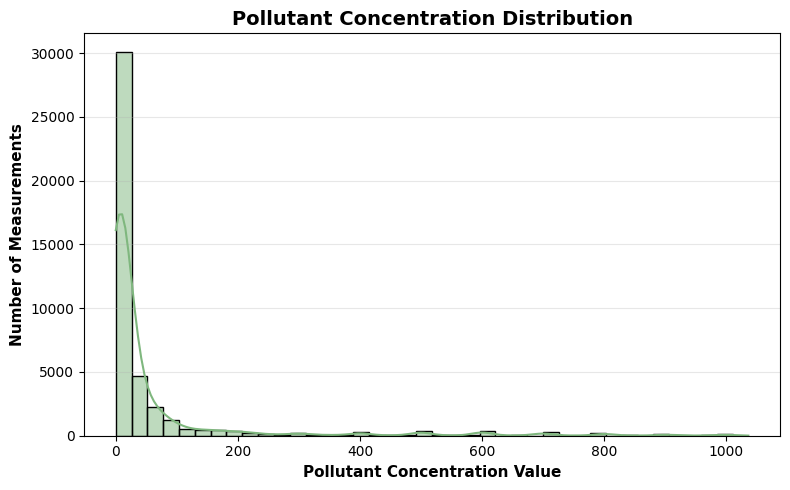

In [358]:
# Pollutant concentration distribution analysis without extreme outliers

filtered_values = (
    clean_openaq[
        clean_openaq["Value"]
        <= clean_openaq["Value"].quantile(0.99)
    ]
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.histplot(
    data=filtered_values,
    x="Value",
    bins=40,
    kde=True,
    color="#7FB77E",
    ax=ax
)


ax.set_title(
    "Pollutant Concentration Distribution",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Pollutant Concentration Value",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Measurements",
    fontsize=11,
    fontweight="bold"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The pollutant concentration distribution shows that most air quality measurements are concentrated at lower concentration values.

A right-skewed distribution can be observed, where a small number of records present higher pollutant concentration levels compared to the majority of observations.

For visualization purposes, extreme values were limited during this exploratory analysis to better understand the general distribution pattern without removing observations from the original dataset.

The presence of high concentration values indicates variability in air pollution measurements and highlights the importance of evaluating outliers before applying Machine Learning models.

- Pollutant Concentration by Air Quality Level

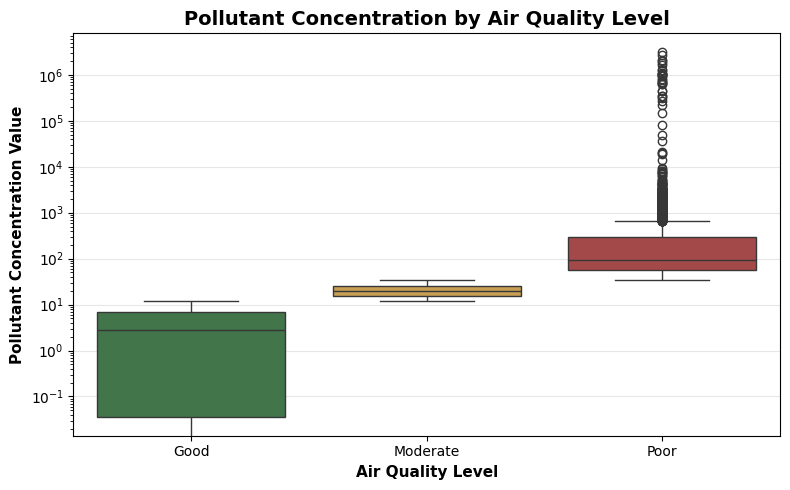

In [359]:
# Pollutant concentration by air quality level

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_openaq,
    x="air_quality",
    y="Value",
    hue="air_quality",
    order=[
        "Good",
        "Moderate",
        "Poor"
    ],
    palette=air_quality_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Pollutant Concentration by Air Quality Level",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Air Quality Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Pollutant Concentration Value",
    fontsize=11,
    fontweight="bold"
)


ax.set_yscale(
    "log"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The relationship between pollutant concentration values and the generated air quality categories shows a clear separation between classification levels.

Measurements classified as **Good Air Quality** contain the lowest pollutant concentrations, while **Moderate Air Quality** presents intermediate values.

The **Poor Air Quality** category contains higher concentration values and greater variability, including several extreme observations.

This behavior confirms that pollutant concentration is strongly related to the target variable and supports the development of a supervised classification model for predicting air quality levels.

### Categorical Variables Analysis

- Pollutant Type and Air Quality Relationship

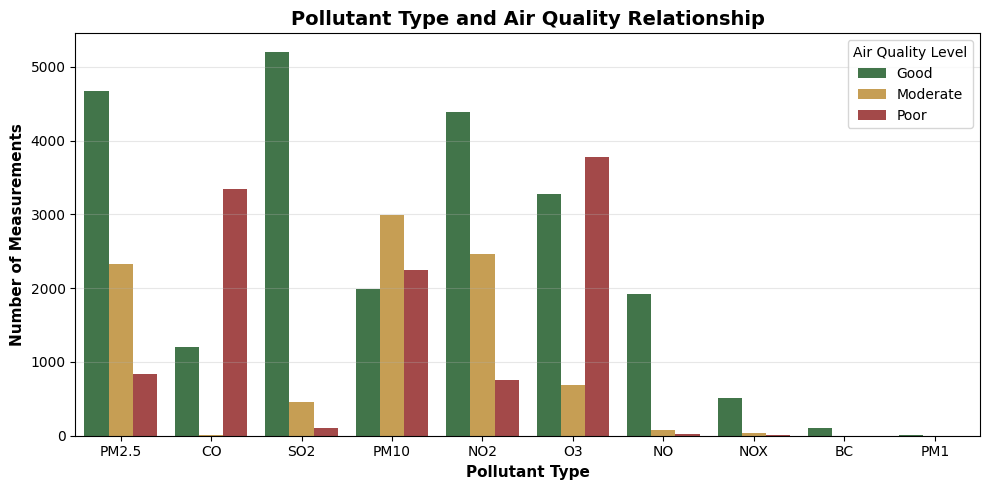

In [360]:
# Pollutant type and air quality relationship

fig, ax = plt.subplots(
    figsize=(10, 5)
)


sns.countplot(
    data=clean_openaq,
    x="Pollutant",
    hue="air_quality",
    hue_order=[
        "Good",
        "Moderate",
        "Poor"
    ],
    palette=air_quality_colors,
    ax=ax
)


ax.set_title(
    "Pollutant Type and Air Quality Relationship",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Pollutant Type",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Measurements",
    fontsize=11,
    fontweight="bold"
)


ax.legend(
    title="Air Quality Level"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The relationship between pollutant type and air quality classification shows that air quality levels vary depending on the measured pollutant.

Pollutants such as **PM2.5, SO2, and NO2** present a higher number of measurements classified as **Good Air Quality**, while pollutants such as **CO and O3** show a greater presence of **Poor Air Quality** observations.

This indicates that pollutant type provides relevant information for understanding air quality conditions and may contribute to predicting the generated classification target.

The differences between pollutant categories suggest that this variable could be useful as a predictive feature in a Machine Learning classification model.

- Country Monitoring Analysis

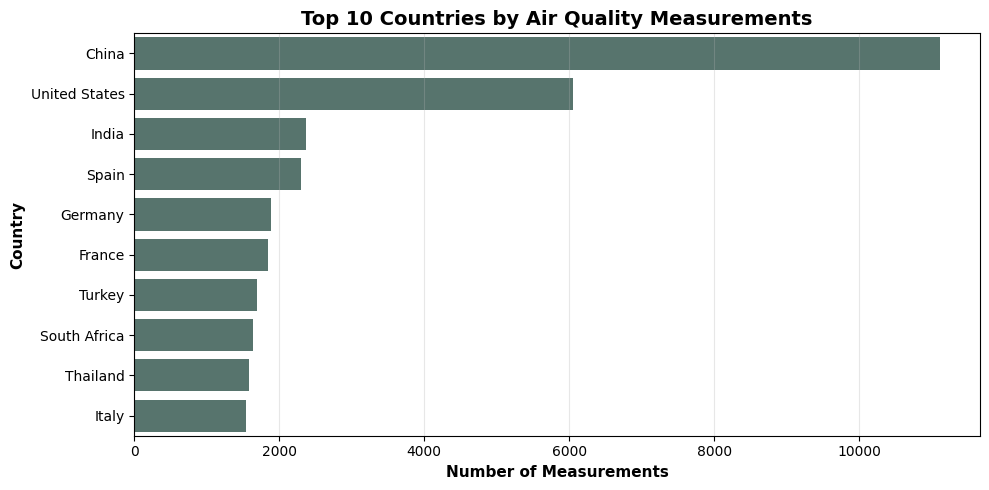

In [361]:
# Top countries by number of monitoring records

top_countries = (
    clean_openaq["Country Label"]
    .value_counts()
    .head(10)
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)


sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    color="#52796F",
    ax=ax
)


ax.set_title(
    "Top 10 Countries by Air Quality Measurements",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Number of Measurements",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Country",
    fontsize=11,
    fontweight="bold"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="x",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The distribution of air quality measurements by country shows an imbalance in the number of monitoring records across geographic regions.

Countries such as **China** and the **United States** contain the highest number of observations, while other countries present considerably fewer records.

This difference indicates that the dataset has uneven geographic representation, which could influence model learning if location-based variables are included.

During Machine Learning development, this imbalance should be considered to avoid models that mainly represent countries with higher data availability.

### Outlier Analysis

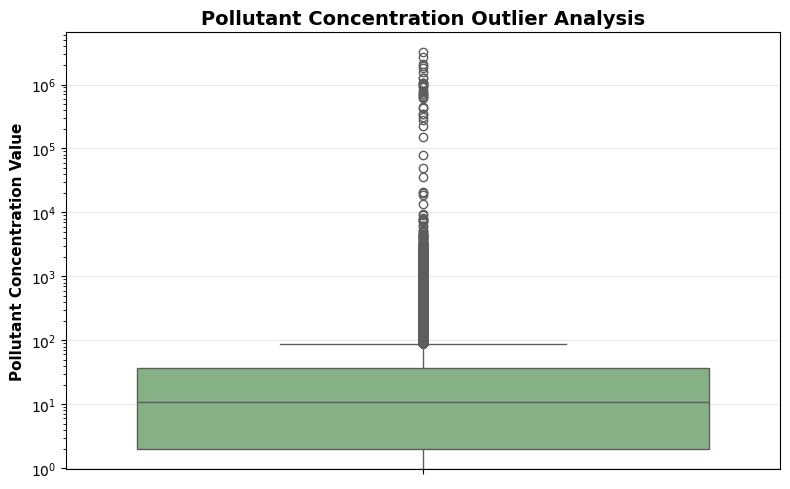

In [362]:
# Outlier analysis for pollutant concentration values

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_openaq,
    y="Value",
    color="#7FB77E",
    ax=ax
)


ax.set_title(
    "Pollutant Concentration Outlier Analysis",
    fontsize=14,
    fontweight="bold"
)


ax.set_ylabel(
    "Pollutant Concentration Value",
    fontsize=11,
    fontweight="bold"
)


ax.set_yscale(
    "log"
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The outlier analysis shows a high variability in pollutant concentration measurements.

Most observations are concentrated within lower concentration ranges, while several measurements appear as extreme values above the typical distribution.

These outliers may be related to high pollution events, differences between pollutant measurement scales, or unusual monitoring conditions.

Because extreme pollutant concentrations can represent relevant environmental events, these observations should not be automatically removed. Instead, preprocessing techniques such as scaling or transformation should be considered before applying Machine Learning models.

### Correlation Analysis

A correlation matrix was evaluated as part of the exploratory data analysis process.

However, the OpenAQ dataset contains only one main numerical predictive variable:

- **Value:** pollutant concentration measurement.

The remaining relevant variables, such as pollutant type, country, location, and air quality classification, are categorical variables and cannot be directly analyzed using a standard Pearson correlation matrix.

Therefore, a numerical correlation heatmap was not generated for this dataset, as it would not provide meaningful relationships between variables.

Instead, relationships between variables were explored through categorical analysis, pollutant comparisons, and air quality distribution visualizations.

## 6. Dataset Evaluation Summary

The exploratory data analysis showed that the OpenAQ dataset contains suitable characteristics to address a Machine Learning classification problem.

The selected problem is the **prediction of air quality conditions**, using **air_quality** as the target variable.

The dataset contains:

- **More than 43,000 air quality monitoring records.**
- Relevant numerical and categorical variables related to pollutant measurements and geographic information.
- A target variable created from pollutant concentration values to enable supervised classification.
- Missing values and inconsistent records treated during the initial data cleaning process.
- Meaningful relationships between pollutant concentration levels, pollutant types, and air quality categories.

The main challenges identified for the next stages are:

- Encoding categorical variables such as pollutant type and geographic information.
- Scaling numerical variables due to the presence of different ranges and extreme values.
- Evaluating outlier treatment strategies while preserving relevant environmental events.
- Applying preprocessing pipelines to ensure reproducibility.
- Training and comparing multiple Machine Learning classification algorithms.
- Optimizing model performance through hyperparameter tuning techniques.

# Dataset 3: CO₂ Global Emissions 1950-2024

## Dataset Overview

The CO₂ Global Emissions dataset contains historical information about carbon dioxide emissions across different countries and years.

The dataset includes environmental indicators related to greenhouse gas emissions, allowing the analysis of global emission patterns and differences between regions.

The main objective of this dataset analysis is to evaluate whether these variables can be used to predict the emission level of a country or region.

**Target variable:** `emission_level`

**Problem type:** Supervised Classification

## 1. Dataset Loading

In [363]:
co2_emissions = pd.read_csv("../datasets/emissioni-co2-globali-per-paese-1950-2024.csv")

In [364]:
co2_emissions.head()

,country,year,iso_code,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,consumption_co2
0,Afghanistan,1950,AFG,0.084272,0.010837,0.021068,0.063204,0.0,0.0,NaN
1,Afghanistan,1951,AFG,0.091600,0.011625,0.025648,0.065952,0.0,0.0,NaN
2,Afghanistan,1952,AFG,0.091600,0.011468,0.031708,0.059892,0.0,0.0,NaN
3,Afghanistan,1953,AFG,0.106256,0.013123,0.037949,0.068307,0.0,0.0,NaN
4,Afghanistan,1954,AFG,0.106256,0.012945,0.042502,0.063754,0.0,0.0,NaN


### Initial Dataset Preview

The first rows of the dataset show historical CO₂ emission records organized by country and year.

Each record represents annual environmental information for a specific country, including geographic identification variables and indicators associated with carbon dioxide emissions.

The dataset structure allows the analysis of emission trends over time and differences between countries, providing information that can be used to evaluate global emission patterns and develop predictive Machine Learning models.

## 2. Initial Exploration

In [365]:
co2_emissions.shape

(14925, 10)

In [366]:
co2_emissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 14925 entries, 0 to 14924
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          14925 non-null  str    
 1   year             14925 non-null  int64  
 2   iso_code         14925 non-null  str    
 3   co2              14086 non-null  float64
 4   co2_per_capita   14086 non-null  float64
 5   coal_co2         10052 non-null  float64
 6   oil_co2          14026 non-null  float64
 7   gas_co2          7765 non-null   float64
 8   cement_co2       13810 non-null  float64
 9   consumption_co2  4064 non-null   float64
dtypes: float64(7), int64(1), str(2)
memory usage: 1.1 MB


### Dataset Structure Analysis

The CO₂ Global Emissions dataset contains **14,925 records and 10 variables** associated with historical carbon dioxide emissions from different countries.

The variables contain different types of information:

- **Categorical variables (object): 2 columns**
  - country
  - iso_code

- **Numerical variables: 8 columns**
  - year
  - co2
  - co2_per_capita
  - coal_co2
  - oil_co2
  - gas_co2
  - cement_co2
  - consumption_co2

The dataset includes temporal information from different years, geographic identification variables, and multiple indicators related to CO₂ emissions generated from different sources.

Several variables present missing values, especially emission indicators associated with specific sources. These missing values will be evaluated during the data cleaning stage.

The objective of this dataset is to analyze global CO₂ emission patterns and evaluate the possibility of creating a Machine Learning classification problem based on emission levels.

### Descriptive Statistics

In [367]:
co2_emissions.describe()

,year,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,consumption_co2
count,14925.000000,14086.000000,14086.000000,10052.000000,14026.000000,7765.000000,13810.000000,4064.000000
mean,1987.000000,111.903296,4.210654,65.221744,40.284451,35.036618,3.525297,237.715854
std,21.649436,550.619005,7.445173,375.399260,171.983789,127.541175,27.716631,824.056666
min,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1968.000000,0.765945,0.362036,0.053592,0.586240,0.172004,0.000000,8.905270
50%,1987.000000,6.390941,1.649128,1.588705,3.312256,3.143712,0.228244,39.178490
75%,2006.000000,43.733862,5.722017,14.730824,19.685696,18.832960,1.357502,149.084835
max,2024.000000,12289.037109,364.790833,8886.020508,2584.129883,1748.137695,828.710022,10857.025391


The descriptive statistics of the numerical variables show the main characteristics of global CO₂ emission records:

- **year:**  
The dataset contains historical emission records between **1950 and 2024**. The average year is around **1987**, indicating that the information covers several decades of global emission data.

- **co2:**  
Total CO₂ emissions show a high variability between countries and years. Values range from **0 to approximately 11,903 million tonnes**, with an average close to **112 million tonnes**, indicating large differences in emission levels among countries.

- **co2_per_capita:**  
CO₂ emissions per person present considerable variation. This variable provides information about the relative emission impact considering population differences between countries.

- **coal_co2:**  
CO₂ emissions associated with coal usage show important differences across observations. Some countries and years present no coal-related emissions, while others show significantly higher values.

- **oil_co2:**  
Oil-related CO₂ emissions also present a wide range of values, reflecting different levels of dependence on fossil fuels between countries.

- **gas_co2:**  
Gas-related emissions contain greater variability and a higher number of missing records, which will require evaluation during the cleaning process.

- **cement_co2:**  
Cement production emissions are generally lower compared with fossil fuel sources but still contribute to total CO₂ emissions.

- **consumption_co2:**  
Consumption-based CO₂ emissions present fewer available records and high variability, indicating differences in data availability and consumption patterns.

Overall, the dataset contains variables with different scales and considerable variability between observations. Missing values, possible outliers, and feature scaling will need to be evaluated before applying Machine Learning models.

### Missing Values Detection

In [368]:
missing_values = (co2_emissions.isnull().sum())
missing_values

country                0
year                   0
iso_code               0
co2                  839
co2_per_capita       839
coal_co2            4873
oil_co2              899
gas_co2             7160
cement_co2          1115
consumption_co2    10861
dtype: int64

The missing values analysis shows that several emission-related variables contain incomplete information.

Missing values were identified in the following variables:

- **co2:** 839 missing records.
- **co2_per_capit:** 839 missing records.
- **coal_co2:** 4,873 missing records.
- **oil_co2:** 899 missing records.
- **gas_co2:** 7,160 missing records.
- **cement_co2:** 1,115 missing records.
- **consumption_co2:** 10,861 missing records.

The variables **country**, **year**, and **iso_code** contain complete information.

The highest amount of missing information is observed in variables related to specific emission sources, especially **consumption_co2** and **gas_co2**.

These missing values may be associated with unavailable historical records, differences in reporting systems between countries, or incomplete emission source measurements.

A missing values treatment strategy will be required before applying Machine Learning models while considering the environmental meaning of each variable.

## 3. Data Cleaning

A copy of the original dataset is created before applying cleaning transformations.

Data cleaning will focus on:

- Detection and correction of inconsistent emission values.
- Evaluation of duplicate records.
- Treatment of missing emission information.
- Verification of dataset consistency before exploratory analysis.

### Data Consistency Check

In [369]:
# Identify negative emission values

emission_columns = [
    "co2",
    "co2_per_capita",
    "coal_co2",
    "oil_co2",
    "gas_co2",
    "cement_co2",
    "consumption_co2"
]


negative_emissions = (
    co2_emissions[
        (
            co2_emissions[
                emission_columns
            ] < 0
        ).any(
            axis=1
        )
    ]
)


negative_emissions

,country,year,iso_code,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,consumption_co2


In [370]:
# Identify duplicated records

co2_emissions.duplicated().sum()

np.int64(0)

The data consistency check was performed to identify possible issues that could affect the quality and reliability of the dataset.

The following aspects were evaluated:

- **Negative emission values:**  
  Emission variables were checked because CO₂ emission measurements cannot represent negative quantities. No negative values were identified, indicating that emission records contain valid numerical values.

- **Duplicate records:**  
  Duplicate observations were reviewed to avoid repeated country-year records influencing the analysis and Machine Learning model development.

The consistency evaluation helps ensure that the dataset contains reliable records before applying cleaning transformations and exploratory analysis.

In [371]:
clean_co2_emissions = (
    co2_emissions.copy()
)

### Missing Values Treatment

In [372]:
# Remove variable with high percentage of missing values

clean_co2_emissions = (
    clean_co2_emissions
    .drop(
        columns=[
            "consumption_co2"
        ]
    )
)

In [373]:
# Replace missing numerical values using the median

emission_columns = [
    "co2",
    "co2_per_capita",
    "coal_co2",
    "oil_co2",
    "gas_co2",
    "cement_co2"
]


for column in emission_columns:

    clean_co2_emissions[column] = (
        clean_co2_emissions[column]
        .fillna(
            clean_co2_emissions[column]
            .median()
        )
    )

Missing values were treated according to the amount of unavailable information and the meaning of each variable.

The variable **consumption_co2** presented a high percentage of missing records, so it was removed to avoid introducing excessive uncertainty into the dataset.

The remaining emission variables were completed using the median value.

The median was selected because emission variables contain extreme differences between countries, and it is less affected by outliers than the mean.

### Cleaning Verification

In [374]:
# Verify missing values after cleaning

clean_co2_emissions.isnull().sum()

country           0
year              0
iso_code          0
co2               0
co2_per_capita    0
coal_co2          0
oil_co2           0
gas_co2           0
cement_co2        0
dtype: int64

In [375]:
# Verify duplicated records after cleaning

clean_co2_emissions.duplicated().sum()

np.int64(0)

### Initial Data Cleaning Results

After applying the initial cleaning process:

- Missing emission values were successfully treated.
- The variable with excessive missing information was removed.
- Duplicate records were evaluated.
- The dataset structure was preserved for emission pattern analysis.
- Numerical variables are prepared for exploratory analysis.

The dataset is now ready for feature engineering and Machine Learning problem definition.

## 4. Feature Engineering

### Target Variable Creation

The original dataset does not contain a predefined classification target variable.

To formulate a supervised Machine Learning problem, a new categorical variable named **emission_level** was created based on total CO₂ emission values.

Emission records were divided into three categories using distribution-based thresholds:

- **Low Emission**
- **Medium Emission**
- **High Emission**

This approach allows countries and years to be classified according to their relative emission levels and enables the development of classification models.

In [376]:
# Create emission level classification target variable

low_threshold = (
    clean_co2_emissions["co2"]
    .quantile(0.33)
)


high_threshold = (
    clean_co2_emissions["co2"]
    .quantile(0.66)
)


def classify_emission_level(value):

    if value <= low_threshold:
        return "Low"

    elif value <= high_threshold:
        return "Medium"

    else:
        return "High"


clean_co2_emissions["emission_level"] = (
    clean_co2_emissions["co2"]
    .apply(classify_emission_level)
)

In [377]:
# Verify target variable creation

clean_co2_emissions[
    "emission_level"
].value_counts()

emission_level
High      5075
Low       4925
Medium    4925
Name: count, dtype: int64

## 5. Exploratory Data Analysis

### Target Variable Analysis

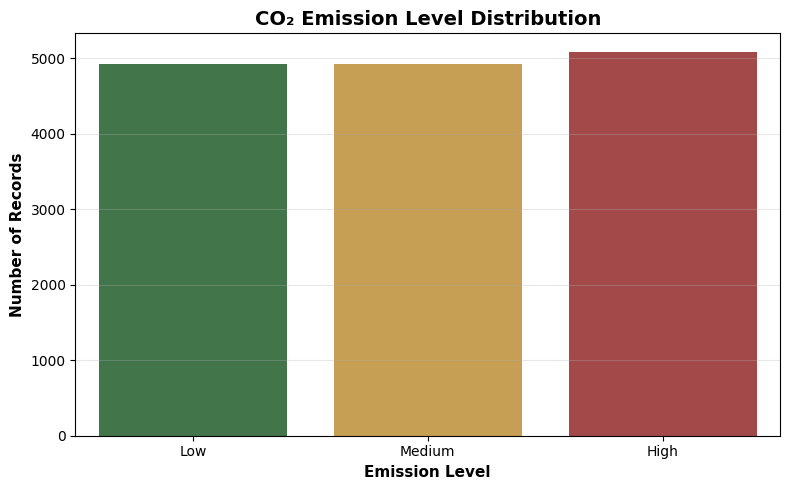

In [378]:
# Emission level distribution

emission_colors = {
    "Low": "#3A7D44",
    "Medium": "#D9A441",
    "High": "#B23A3A"
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    data=clean_co2_emissions,
    x="emission_level",
    hue="emission_level",
    order=[
        "Low",
        "Medium",
        "High"
    ],
    palette=emission_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "CO₂ Emission Level Distribution",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Emission Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Records",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The distribution of the created emission level classification variable shows a balanced representation between the three categories: **Low**, **Medium**, and **High** emissions.

This balanced distribution is a result of using data-driven thresholds based on CO₂ emission percentiles, allowing emission records to be grouped according to their relative levels.

The absence of a significant class imbalance represents an advantage for Machine Learning model development, since classification algorithms can learn patterns from each category with similar representation.

The created **emission_level** variable enables the dataset to be used as a supervised classification problem.

### Numerical Variables Analysis

- CO₂ Emission Distribution

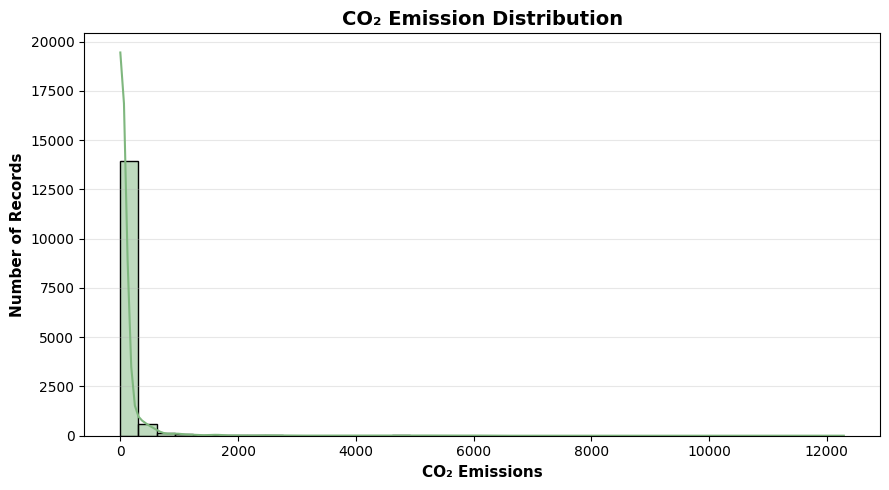

In [379]:
# CO2 emission distribution

fig, ax = plt.subplots(
    figsize=(9, 5)
)


sns.histplot(
    data=clean_co2_emissions,
    x="co2",
    bins=40,
    color="#7FB77E",
    kde=True,
    ax=ax
)


ax.set_title(
    "CO₂ Emission Distribution",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "CO₂ Emissions",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Records",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The distribution of total CO₂ emissions shows a strong right-skewed pattern.

Most country-year records are concentrated in lower emission ranges, while a smaller number of observations present significantly higher emission values.

This behavior reflects the differences in emission levels between countries, where a limited number of countries contribute substantially higher amounts of CO₂ emissions.

The presence of a wide range of values indicates that scaling or transformation techniques should be considered before applying Machine Learning models.

- CO₂ Emissions by Emission Level

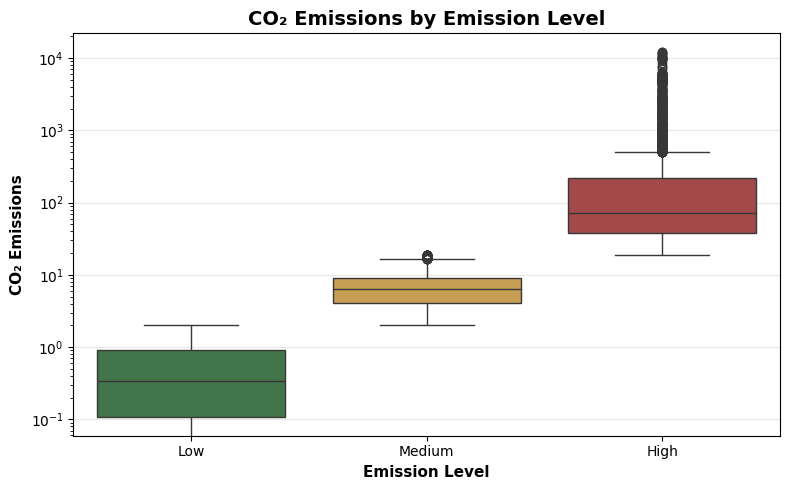

In [380]:
# CO2 emissions by emission level

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_co2_emissions,
    x="emission_level",
    y="co2",
    hue="emission_level",
    order=[
        "Low",
        "Medium",
        "High"
    ],
    hue_order=[
        "Low",
        "Medium",
        "High"
    ],
    palette=emission_colors,
    legend=False,
    ax=ax
)



ax.set_title(
    "CO₂ Emissions by Emission Level",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Emission Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "CO₂ Emissions",
    fontsize=11,
    fontweight="bold"
)


ax.set_yscale(
    "log"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The comparison of CO₂ emissions across the created emission categories shows a clear separation between **Low**, **Medium**, and **High** emission levels.

The **High Emission** category presents greater variability and contains several extreme values, representing countries and years with substantially higher CO₂ emissions.

The separation between categories confirms that the created **emission_level** target variable correctly represents different emission patterns.

These differences indicate that CO₂-related variables may provide useful information for a Machine Learning classification model.

- Emission Sources Comparison (coal/oil/gas)

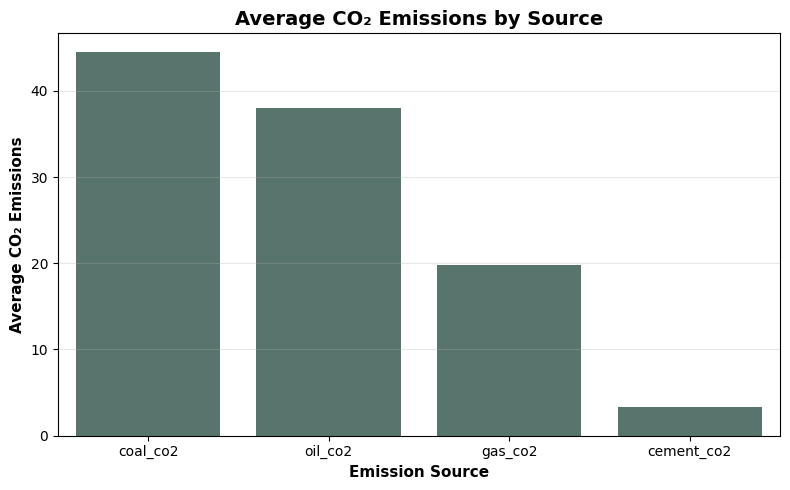

In [381]:
# Average emissions by source

source_means = (
    clean_co2_emissions[
        [
            "coal_co2",
            "oil_co2",
            "gas_co2",
            "cement_co2"
        ]
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.barplot(
    x=source_means.index,
    y=source_means.values,
    color="#52796F",
    ax=ax
)


ax.set_title(
    "Average CO₂ Emissions by Source",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Emission Source",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Average CO₂ Emissions",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The analysis of average CO₂ emissions by source shows differences in the contribution of each emission category.

Coal-related emissions represent the highest average contribution, followed by oil and gas emissions.

Cement-related emissions present a considerably lower average contribution compared with fossil fuel sources.

These differences highlight the importance of emission source variables for understanding global CO₂ patterns and their potential relevance as predictive features in Machine Learning models.

### Categorical Variables Analysis

- Countries by Predominant Emission Level

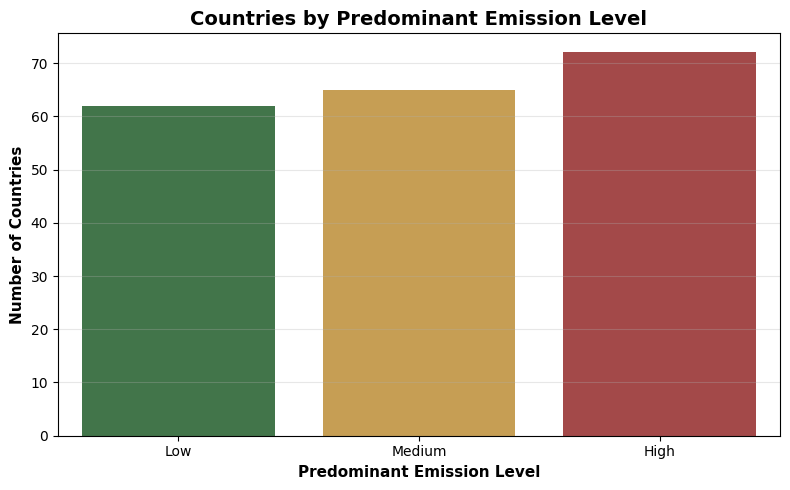

In [382]:
# Number of countries by predominant emission level

country_emission_level = (
    clean_co2_emissions
    .groupby("country")["emission_level"]
    .agg(
        lambda x: x.mode()[0]
    )
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    x=country_emission_level,
    hue=country_emission_level,
    order=[
        "Low",
        "Medium",
        "High"
    ],
    palette=emission_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Countries by Predominant Emission Level",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Predominant Emission Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Countries",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The analysis of the predominant emission level by country shows how countries are distributed according to their most frequent historical CO₂ emission category.

The results show that countries are represented across the three emission groups: **Low**, **Medium**, and **High**, with a slightly higher number of countries classified as having predominantly high emission levels.

This distribution indicates differences in long-term emission patterns between countries, reflecting variations in industrial development, energy consumption, and emission sources.

The geographic variability observed suggests that country-related information may provide useful context for understanding global CO₂ emission behavior.

- Top Countries by Average CO₂ Emissions

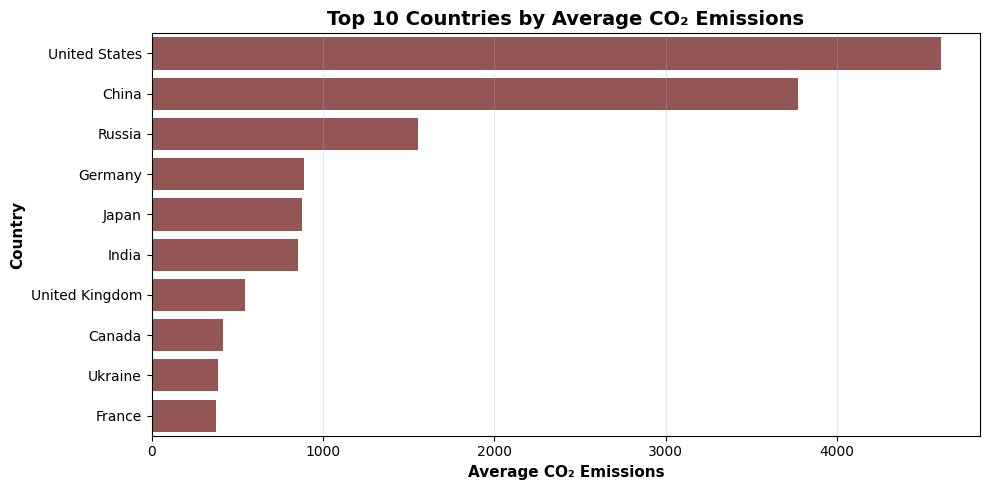

In [383]:
# Top countries by average CO2 emissions

top_emitters = (
    clean_co2_emissions
    .groupby("country")["co2"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)


sns.barplot(
    x=top_emitters.values,
    y=top_emitters.index,
    color="#9E4A4A",
    ax=ax
)


ax.set_title(
    "Top 10 Countries by Average CO₂ Emissions",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Average CO₂ Emissions",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Country",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="x",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The analysis of average CO₂ emissions by country shows significant differences in emission levels between geographic regions.

Countries such as the **United States** and **China** present the highest average CO₂ emissions across the historical period analyzed.

The differences between countries reflect variations in industrial activity, population size, energy consumption, and dependence on fossil fuels.

This geographic variability suggests that country-related information may contribute to identifying emission patterns in a Machine Learning classification model.

### Outliers Analysis

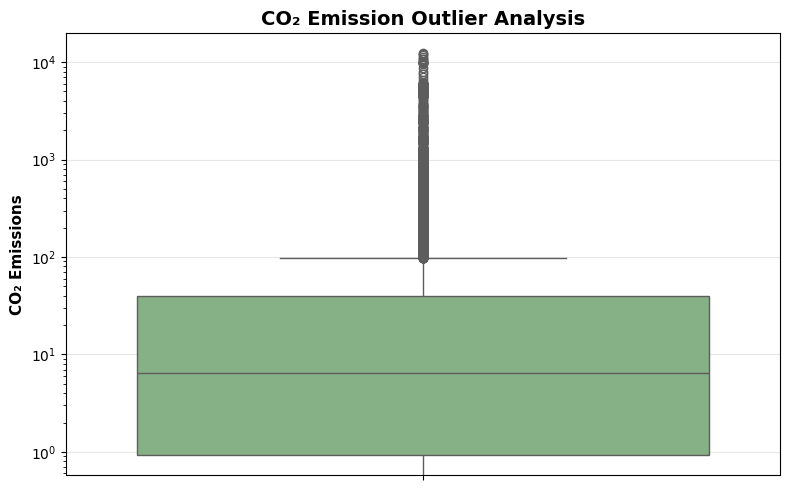

In [384]:
# CO2 emission outlier analysis

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_co2_emissions,
    y="co2",
    color="#7FB77E",
    ax=ax
)


ax.set_title(
    "CO₂ Emission Outlier Analysis",
    fontsize=14,
    fontweight="bold"
)


ax.set_ylabel(
    "CO₂ Emissions",
    fontsize=11,
    fontweight="bold"
)


ax.set_yscale(
    "log"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The outlier analysis shows a highly skewed distribution of total CO₂ emissions, with several observations located above the typical range.

Most country-year records are concentrated in lower emission values, while a smaller group presents substantially higher CO₂ emissions.

These extreme observations are expected in global emission datasets because countries differ significantly in population size, industrial activity, and fossil fuel consumption.

Therefore, these values should not be automatically removed, as they represent meaningful environmental patterns rather than data errors.

For Machine Learning modeling, scaling or transformation techniques should be considered to reduce the influence of extreme values while preserving important emission information.

### Correlation Analysis

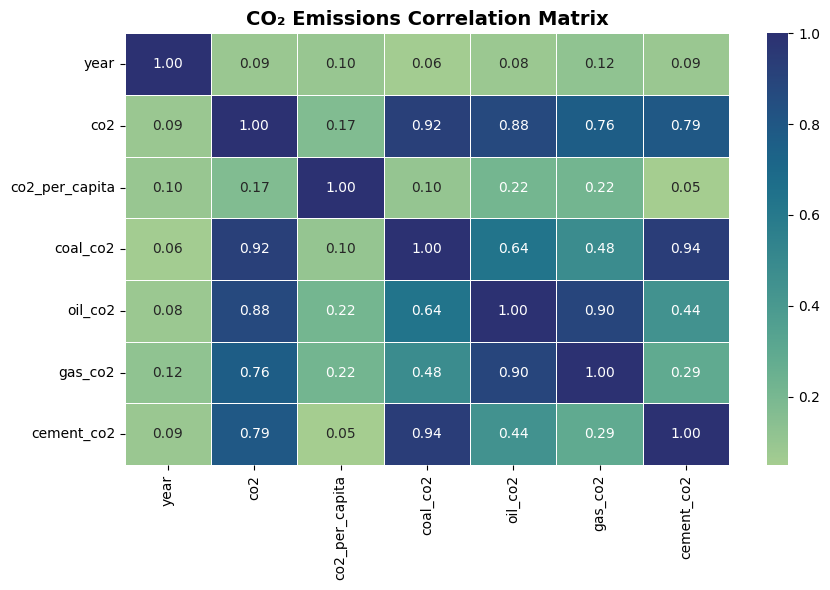

In [385]:
# Correlation matrix for numerical variables

correlation_matrix = (
    clean_co2_emissions[
        [
            "year",
            "co2",
            "co2_per_capita",
            "coal_co2",
            "oil_co2",
            "gas_co2",
            "cement_co2"
        ]
    ]
    .corr()
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)


sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="crest",
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)


ax.set_title(
    "CO₂ Emissions Correlation Matrix",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()

plt.show()

The correlation matrix shows the relationships between numerical variables associated with global CO₂ emissions.

Total CO₂ emissions present strong positive correlations with the main emission source variables:

- **coal_co2:** strong positive correlation with total CO₂ emissions.
- **oil_co2:** strong positive correlation with total CO₂ emissions.
- **gas_co2:** strong positive correlation with total CO₂ emissions.
- **cement_co2:** strong positive correlation with total CO₂ emissions.

This indicates that increases in fossil fuel and industrial emission sources are strongly associated with higher total CO₂ emission levels.

Some emission source variables also present strong relationships between each other, such as oil and gas emissions, suggesting that countries with higher energy-related emissions often present increases across multiple sources.

The variable **co2_per_capita** shows a weaker relationship with total CO₂ emissions, indicating that emissions per person capture different information compared with total national emissions.

These correlations should be considered during Machine Learning development, since highly correlated predictors may provide strong predictive information but could also introduce feature redundancy.

## 6. Dataset Evaluation Summary

The exploratory data analysis showed that the CO₂ Global Emissions dataset contains suitable characteristics to address a Machine Learning classification problem.

The selected problem is the **prediction of global CO₂ emission levels**, using **emission_level** as the target variable.

The dataset contains:

- **14,925 historical emission records from different countries.**
- Relevant numerical and categorical variables related to geographic information, time periods, and CO₂ emission sources.
- A target variable created from total CO₂ emission values using distribution-based thresholds.
- Missing emission information treated during the initial data cleaning process.
- Meaningful relationships between total CO₂ emissions, emission sources, and emission level categories.
- Strong correlations between fossil fuel-related variables and total CO₂ emissions.

The main challenges identified for the next stages are:

- Encoding categorical variables such as country information.
- Scaling numerical variables due to different ranges and significant differences in emission magnitudes.
- Evaluating outlier treatment strategies while preserving relevant environmental emission patterns.
- Managing highly correlated variables to reduce possible feature redundancy.
- Applying preprocessing pipelines to ensure reproducibility.
- Training and comparing multiple Machine Learning classification algorithms.
- Optimizing model performance through hyperparameter tuning techniques.

# Dataset 4: Global Climate Energy 2020-2024

## Dataset Overview

The Global Climate Energy dataset contains information about climate and energy indicators from different countries between 2020 and 2024.

The dataset includes variables related to environmental conditions, energy production or consumption, and sustainability indicators.

The main objective of this dataset analysis is to evaluate whether these variables can be used to develop a Machine Learning classification model related to climate or energy patterns.

A target variable will be selected or created after analyzing the available features and dataset structure.

**Problem type:** Supervised Classification

## 1. Dataset Loading

In [386]:
climate_energy = pd.read_csv("../datasets/global_climate_energy_2020_2024.csv")

In [387]:
climate_energy.head()

,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


### Initial Dataset Preview

The first rows of the dataset show climate and energy records organized by country and date.

Each record represents environmental and energy-related information for a specific country, including climate indicators, CO₂ emissions, energy consumption, renewable energy participation, population characteristics, industrial activity, and energy prices.

The dataset structure allows the analysis of relationships between climate conditions, energy patterns, and sustainability indicators, providing information that can be used to develop predictive Machine Learning models.

## 2. Initial Exploration

In [388]:
climate_energy.shape

(36540, 10)

In [389]:
climate_energy.info()

<class 'pandas.DataFrame'>
RangeIndex: 36540 entries, 0 to 36539
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       36540 non-null  str    
 1   country                    36540 non-null  str    
 2   avg_temperature            36540 non-null  float64
 3   humidity                   36540 non-null  float64
 4   co2_emission               36540 non-null  float64
 5   energy_consumption         36540 non-null  float64
 6   renewable_share            36540 non-null  float64
 7   urban_population           36540 non-null  float64
 8   industrial_activity_index  36540 non-null  float64
 9   energy_price               36540 non-null  float64
dtypes: float64(8), str(2)
memory usage: 2.8 MB


### Dataset Structure Analysis

The Global Climate Energy dataset contains **36,540 records and 10 variables** associated with climate conditions, energy consumption, and sustainability indicators.

The variables present different types of information:

- **Categorical variables (object): 2 columns**
  - date
  - country

- **Numerical variables: 8 columns**
  - avg_temperature
  - humidity
  - co2_emission
  - energy_consumption
  - renewable_share
  - urban_population
  - industrial_activity_index
  - energy_price

No missing values were identified during the initial structure analysis, indicating that all variables contain complete information.

The dataset includes environmental, demographic, and energy-related indicators that can be analyzed to identify sustainability patterns.

A classification target variable will be created during the feature engineering stage to formulate a supervised Machine Learning problem.

In [390]:
climate_energy.describe()

,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
count,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000
mean,13.580868,59.971469,445.820452,7295.904857,15.944080,74.982156,70.173094,115.279848
std,10.077249,17.303103,234.360906,3693.928504,5.334804,8.645400,17.334816,49.178361
min,-9.600000,30.000000,50.150000,1001.890000,5.000000,60.000000,40.000000,30.000000
25%,5.630000,45.010000,248.675000,4184.177500,12.020000,67.470000,55.300000,72.420000
50%,13.790000,59.990000,422.655000,6921.620000,15.715000,75.030000,70.055000,115.240000
75%,20.840000,74.970000,628.422500,10175.110000,19.840000,82.502500,85.260000,158.270000
max,38.710000,90.000000,999.850000,15998.050000,30.870000,90.000000,100.000000,200.000000


### Descriptive Statistics Analysis

The statistical analysis of the numerical variables shows the main characteristics of the climate and energy indicators:

- **avg_temperature:**  
The average temperature is approximately 13.6°C, with values ranging from -9.6°C to 38.7°C. This range represents different climate conditions across countries and time periods.

- **humidity:**  
The average humidity level is around 60%. Values range between 30% and 90%, showing variability in environmental conditions between regions.

- **co2_emission:**  
CO₂ emission values present differences between countries and periods, reflecting variations in industrial activity, energy consumption, and environmental impact.

- **energy_consumption:**  
Energy consumption shows variability across records, indicating differences in energy demand between countries.

- **renewable_share:**  
The renewable energy participation variable represents the percentage of energy coming from renewable sources, allowing the evaluation of sustainability-related patterns.

- **urban_population:**  
Urban population values show differences in population distribution and development levels among countries.

- **industrial_activity_index:**  
The industrial activity index ranges from 40 to 100, representing different levels of economic and industrial activity.

- **energy_price:**  
Energy prices vary between approximately 30 and 200 units, indicating differences in energy markets and economic conditions.

Overall, the dataset contains numerical variables with different scales and ranges. Therefore, feature scaling should be considered before applying Machine Learning algorithms.

### Missing Values Detection

In [391]:
missing_values = (climate_energy.isnull().sum())
missing_values

date                         0
country                      0
avg_temperature              0
humidity                     0
co2_emission                 0
energy_consumption           0
renewable_share              0
urban_population             0
industrial_activity_index    0
energy_price                 0
dtype: int64

The missing values analysis shows that the dataset does not contain missing records in any variable.

All **36,540 records** contain complete information for the 10 available variables, including climate indicators, energy-related variables, geographic information, and economic indicators.

Since no missing values were identified, no imputation methods or record removal strategies are required during the data cleaning stage.

This indicates good initial data quality and allows the dataset to continue directly to consistency verification and exploratory analysis.

## 3. Data Cleaning

### Data Consistency Check

In [392]:
climate_energy.duplicated().sum()

np.int64(0)

In [393]:
# Identify negative values in numerical variables

numeric_columns = [
    "humidity",
    "co2_emission",
    "energy_consumption",
    "renewable_share",
    "urban_population",
    "industrial_activity_index",
    "energy_price"
]


climate_energy[
    (
        climate_energy[
            numeric_columns
        ] < 0
    )
    .any(
        axis=1
    )
]

,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price


In [394]:
# Check date range

pd.to_datetime(
    climate_energy["date"]
).describe()

count                  36540
mean     2022-07-02 00:00:00
min      2020-01-01 00:00:00
25%      2021-04-01 00:00:00
50%      2022-07-02 00:00:00
75%      2023-10-02 00:00:00
max      2024-12-31 00:00:00
Name: date, dtype: object

The data consistency verification was performed to identify possible quality issues before exploratory analysis and Machine Learning development.

The following aspects were evaluated:

- **Duplicate records:**  
  No duplicated observations were identified in the dataset.

- **Negative values:**  
  Numerical variables where negative values are not expected, such as CO₂ emissions, energy consumption, renewable share, population indicators, industrial activity, and energy prices, were checked. No invalid negative values were detected.

- **Date consistency:**  
  The date variable was converted and evaluated successfully. Records cover the period between **January 2020 and December 2024**, which matches the expected temporal range of the dataset.

The consistency analysis indicates that the dataset presents good data quality and does not require correction of invalid values before the exploratory analysis stage.

### Missing Values Treatment

Since no missing values were identified during the initial exploration stage, no imputation methods were required.

All records were preserved, maintaining the complete dataset structure for the following analysis stages.

In [395]:
# Create a copy of the original dataset

clean_climate_energy = (
    climate_energy.copy()
)

### Cleaning Verification

In [396]:
clean_climate_energy.isnull().sum()

date                         0
country                      0
avg_temperature              0
humidity                     0
co2_emission                 0
energy_consumption           0
renewable_share              0
urban_population             0
industrial_activity_index    0
energy_price                 0
dtype: int64

In [397]:
clean_climate_energy.duplicated().sum()

np.int64(0)

The cleaning verification confirms that the dataset is ready for exploratory analysis and Machine Learning preparation.

After the validation process:

- No missing values are present in the dataset.
- No duplicated records were identified.
- The original number of records was preserved.

Since no inconsistencies were detected, no data removal or imputation procedures were required.

The final cleaned dataset maintains **36,540 records and 10 variables**, ensuring that all available information can be used in the next analysis stages.

## 4. Feature Engineering

### Target Variable Creation

The original dataset does not contain a predefined classification target variable.

To formulate a supervised Machine Learning classification problem, a new categorical variable named **sustainability_level** was created using the renewable energy share indicator.

Records were divided into three sustainability categories according to renewable energy participation:

- **Low Sustainability**
- **Medium Sustainability**
- **High Sustainability**

A distribution-based approach was used to create balanced categories and represent different renewable energy adoption levels.

The created target variable enables the development of classification models focused on sustainability patterns.

In [398]:
# Create sustainability level classification target variable

low_threshold = (
    clean_climate_energy["renewable_share"]
    .quantile(0.33)
)


high_threshold = (
    clean_climate_energy["renewable_share"]
    .quantile(0.66)
)


def classify_sustainability(value):

    if value <= low_threshold:
        return "Low"

    elif value <= high_threshold:
        return "Medium"

    else:
        return "High"


clean_climate_energy["sustainability_level"] = (
    clean_climate_energy[
        "renewable_share"
    ]
    .apply(
        classify_sustainability
    )
)

In [399]:
# Verify target variable creation

clean_climate_energy[
    "sustainability_level"
].value_counts()

sustainability_level
High      12423
Low       12063
Medium    12054
Name: count, dtype: int64

## 5. Exploratory Data Analysis

### Target Variable Analysis

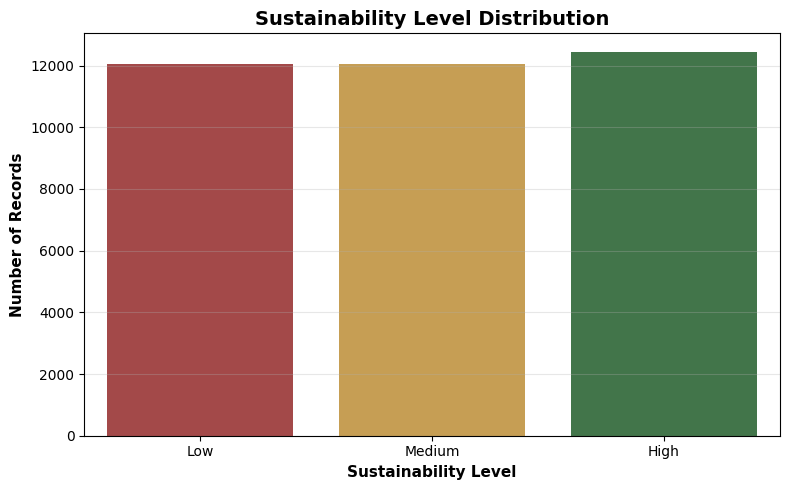

In [400]:
# Sustainability level distribution

sustainability_colors = {
    "Low": "#B23A3A",
    "Medium": "#D9A441",
    "High": "#3A7D44"
}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    data=clean_climate_energy,
    x="sustainability_level",
    hue="sustainability_level",
    order=[
        "Low",
        "Medium",
        "High"
    ],
    palette=sustainability_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Sustainability Level Distribution",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Sustainability Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Records",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The distribution of the created sustainability classification variable shows a balanced representation across the three categories: **Low**, **Medium**, and **High** sustainability levels.

This balance is a result of using distribution-based thresholds from the renewable energy share variable, allowing records to be classified according to their relative renewable energy participation.

The absence of a significant class imbalance represents an advantage for Machine Learning model development, since classification algorithms can learn patterns from all sustainability categories with similar representation.

The created **sustainability_level** variable provides a suitable target for developing a supervised classification model focused on energy sustainability patterns.

### Numerical Variables Analysis

- Renewable Share Distribution

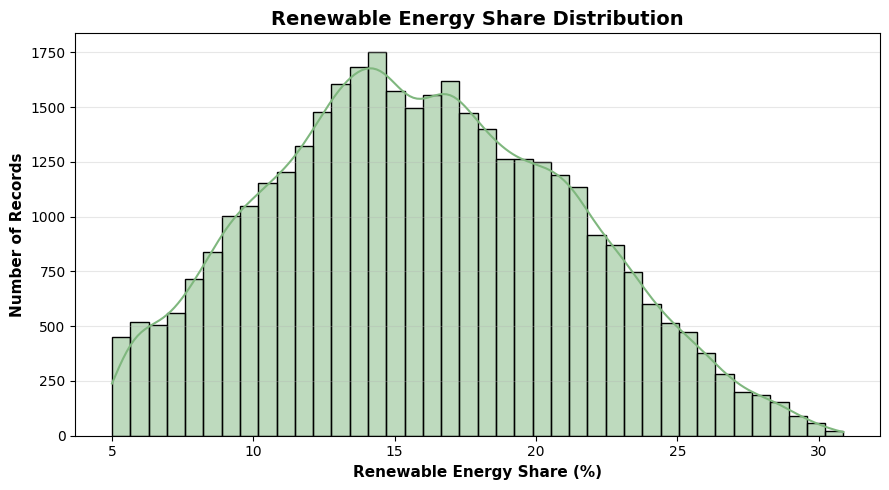

In [401]:
# Renewable energy share distribution

fig, ax = plt.subplots(
    figsize=(9, 5)
)


sns.histplot(
    data=clean_climate_energy,
    x="renewable_share",
    bins=40,
    kde=True,
    color="#7FB77E",
    ax=ax
)


ax.set_title(
    "Renewable Energy Share Distribution",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Renewable Energy Share (%)",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Records",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The renewable energy share distribution shows how renewable energy participation varies across the dataset records.

Most observations are concentrated around intermediate renewable energy percentages, while fewer records are found at very low or very high renewable participation levels.

The distribution indicates variability in renewable energy adoption among countries and time periods.

Since this variable was used to create the **sustainability_level** target variable, it provides the main reference for separating sustainability categories.

- CO₂ Emissions by Sustainability Level

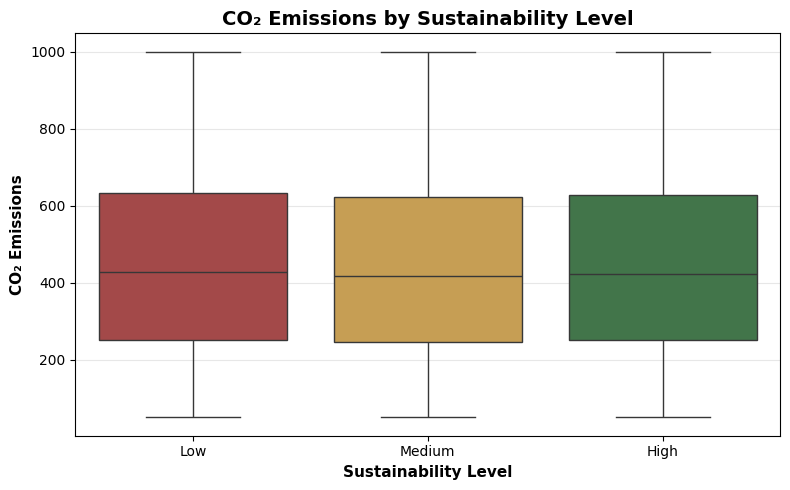

In [402]:
# CO2 emissions by sustainability level

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_climate_energy,
    x="sustainability_level",
    y="co2_emission",
    hue="sustainability_level",
    order=[
        "Low",
        "Medium",
        "High"
    ],
    palette=sustainability_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "CO₂ Emissions by Sustainability Level",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Sustainability Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "CO₂ Emissions",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The comparison of CO₂ emissions across sustainability levels shows similar distributions between **Low**, **Medium**, and **High** sustainability categories.

The median values and variability are relatively close across all groups, suggesting that CO₂ emissions alone do not clearly separate sustainability levels in this dataset.

This indicates that sustainability classification may depend on the combination of multiple environmental and energy-related variables rather than a single predictor.

Further Machine Learning analysis will help evaluate which variables contribute most to predicting sustainability patterns.

- Energy Consumption by Sustainability Level

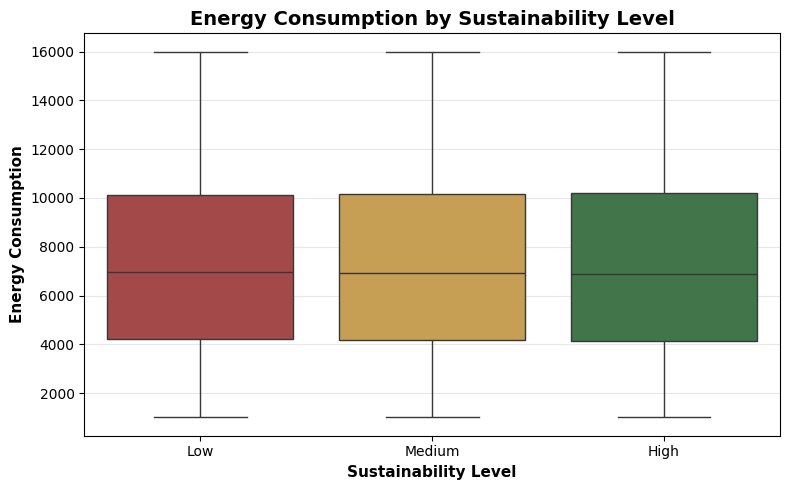

In [403]:
# Energy consumption by sustainability level

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_climate_energy,
    x="sustainability_level",
    y="energy_consumption",
    hue="sustainability_level",
    order=[
        "Low",
        "Medium",
        "High"
    ],
    palette=sustainability_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Energy Consumption by Sustainability Level",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Sustainability Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Energy Consumption",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The analysis of energy consumption across sustainability levels shows comparable distributions among the three categories.

Energy consumption values present a wide range in all sustainability groups, indicating differences in energy demand between records.

The similarity between categories suggests that high energy consumption does not necessarily correspond to lower sustainability levels, especially when renewable energy participation is considered.

Additional variables such as renewable share, emissions, and industrial indicators should be analyzed together to understand sustainability patterns.

### Categorical Variables Analysis

- Countries by Predominant Sustainability Level

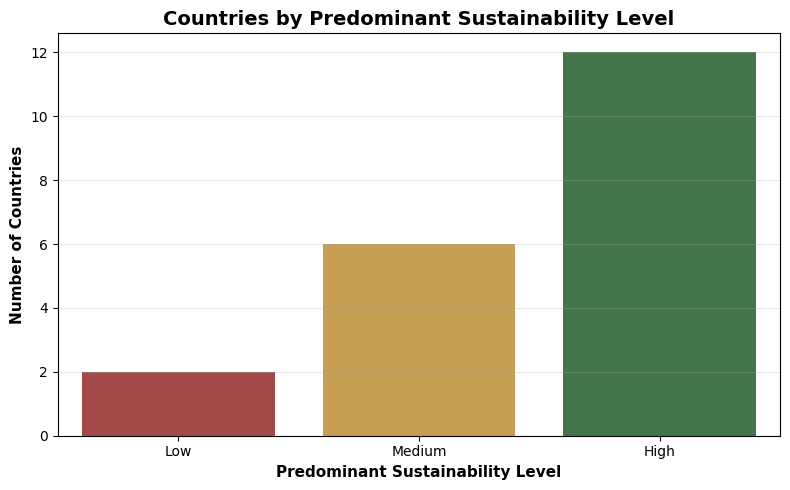

In [404]:
# Number of countries by predominant sustainability level

country_sustainability_level = (
    clean_climate_energy
    .groupby("country")["sustainability_level"]
    .agg(
        lambda x: x.mode()[0]
    )
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.countplot(
    x=country_sustainability_level,
    hue=country_sustainability_level,
    order=[
        "Low",
        "Medium",
        "High"
    ],
    palette=sustainability_colors,
    legend=False,
    ax=ax
)


ax.set_title(
    "Countries by Predominant Sustainability Level",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Predominant Sustainability Level",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Number of Countries",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The analysis of predominant sustainability levels by country shows differences in renewable energy adoption patterns across geographic regions.

Most countries in the dataset are classified as having a predominantly **High Sustainability** level, while fewer countries are mainly represented by **Medium** or **Low Sustainability** categories.

This indicates that, during the analyzed period, several countries present higher relative renewable energy participation according to the created classification criteria.

Country-level differences may provide useful contextual information for understanding sustainability patterns and developing Machine Learning classification models.

- Renewable Energy Share Trend Over Time

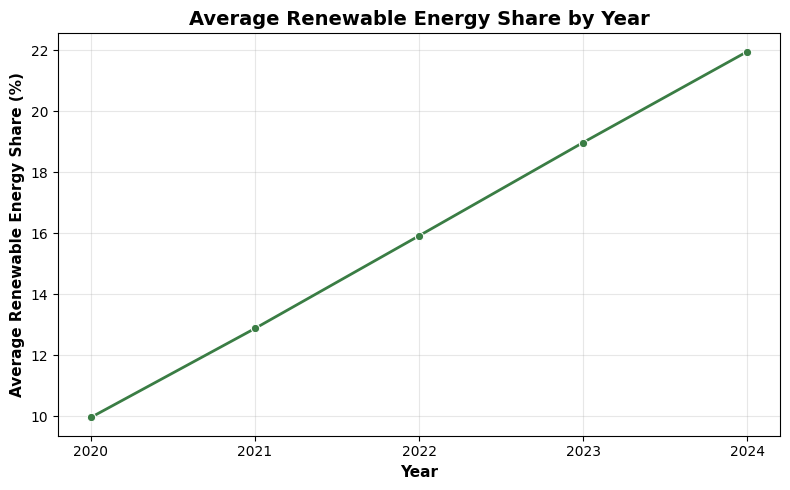

In [405]:
# Average renewable energy share by year

clean_climate_energy["year"] = (
    pd.to_datetime(
        clean_climate_energy["date"]
    )
    .dt.year
)


renewable_trend = (
    clean_climate_energy
    .groupby("year")["renewable_share"]
    .mean()
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.lineplot(
    x=renewable_trend.index,
    y=renewable_trend.values,
    marker="o",
    color="#3A7D44",
    linewidth=2,
    ax=ax
)


ax.set_title(
    "Average Renewable Energy Share by Year",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Year",
    fontsize=11,
    fontweight="bold"
)


ax.set_ylabel(
    "Average Renewable Energy Share (%)",
    fontsize=11,
    fontweight="bold"
)

ax.set_xticks(
    renewable_trend.index
)

ax.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()

The renewable energy share trend shows a continuous increase between 2020 and 2024.

The average renewable energy participation rises from approximately 10% in 2020 to more than 20% in 2024, indicating a progressive transition toward higher renewable energy adoption during the analyzed period.

This temporal behavior suggests that renewable energy participation changes over time and that temporal variables can provide useful information when analyzing sustainability patterns.

The increasing trend supports the relevance of renewable energy indicators for developing Machine Learning models focused on sustainability classification.

### Outlier Analysis

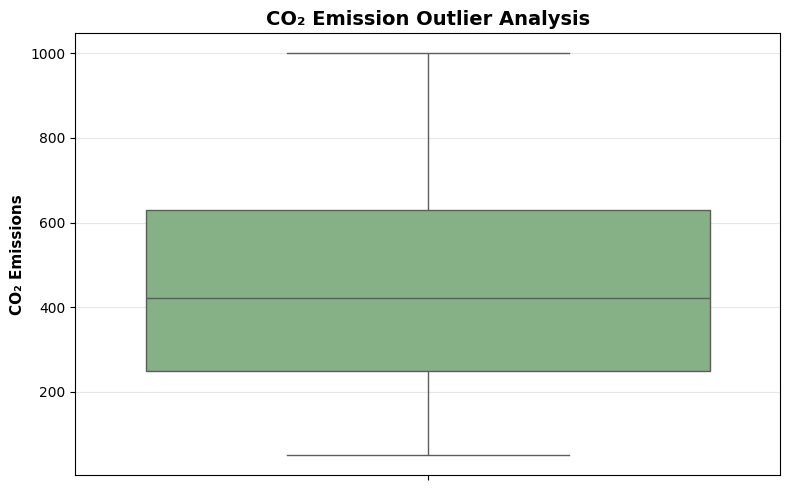

In [406]:
# CO2 emission outlier analysis

fig, ax = plt.subplots(
    figsize=(8, 5)
)


sns.boxplot(
    data=clean_climate_energy,
    y="co2_emission",
    color="#7FB77E",
    ax=ax
)


ax.set_title(
    "CO₂ Emission Outlier Analysis",
    fontsize=14,
    fontweight="bold"
)


ax.set_ylabel(
    "CO₂ Emissions",
    fontsize=11,
    fontweight="bold"
)


ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.show()

The outlier analysis was performed to identify possible extreme values in CO₂ emission measurements.

The boxplot shows that CO₂ emissions are distributed within the expected range, with no significant outliers detected according to the interquartile range method.

The values present natural variability across the dataset, representing differences in environmental and energy conditions between records.

Since no abnormal extreme values were identified, no outlier removal or transformation procedures were required before Machine Learning development.

### Correlation Analysis

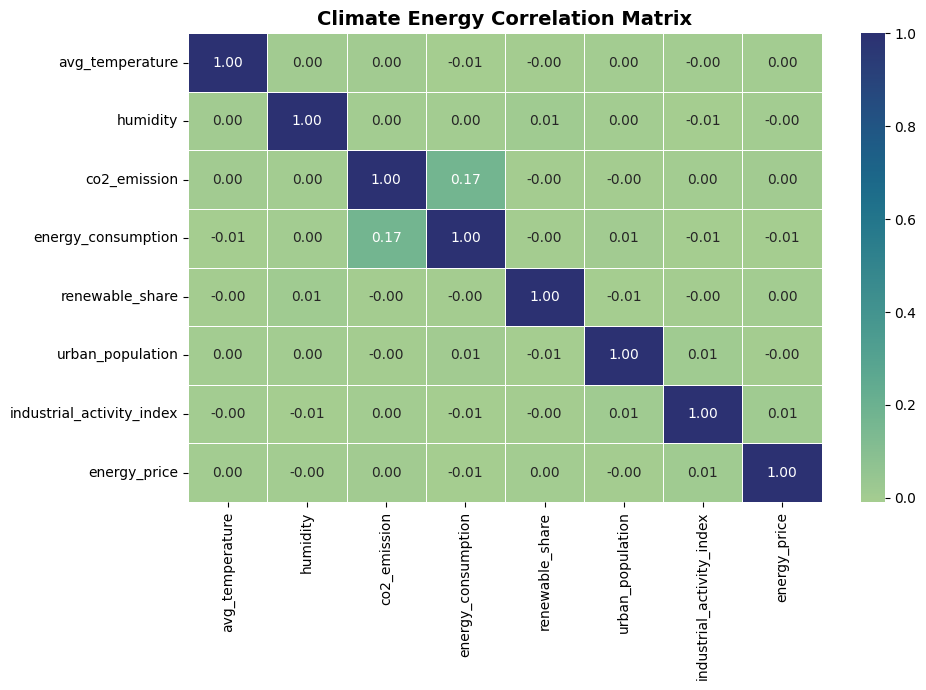

In [407]:
# Correlation matrix for numerical variables

correlation_matrix = (
    clean_climate_energy[
        [
            "avg_temperature",
            "humidity",
            "co2_emission",
            "energy_consumption",
            "renewable_share",
            "urban_population",
            "industrial_activity_index",
            "energy_price"
        ]
    ]
    .corr()
)


fig, ax = plt.subplots(
    figsize=(10, 7)
)


sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="crest",
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)


ax.set_title(
    "Climate Energy Correlation Matrix",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()

plt.show()

The correlation matrix was generated to evaluate relationships between numerical climate and energy variables.

The results show that most variables present very weak correlations, with values close to zero. This indicates that variables such as temperature, humidity, renewable energy share, population indicators, industrial activity, and energy prices behave mostly independently within this dataset.

A weak positive correlation is observed between **CO₂ emissions** and **energy consumption**, suggesting that higher energy use may be slightly associated with higher emission levels.

No strong multicollinearity was detected among the numerical variables, which is beneficial for Machine Learning development because the features provide different types of information.

The analysis suggests that sustainability classification may depend on the combination of multiple variables rather than a single strongly correlated predictor.

## 6. Dataset Evaluation Summary

The exploratory data analysis showed that the Global Climate Energy dataset contains suitable characteristics to address a Machine Learning classification problem.

The selected problem is the **prediction of sustainability level**, using **sustainability_level** as the target variable.

The dataset contains:

- **36,540 climate and energy records.**
- Environmental, energy, demographic, and economic indicators from different countries between 2020 and 2024.
- Complete information with no missing values identified during the initial exploration process.
- No duplicated records or significant data inconsistencies detected during data validation.
- A balanced target variable created from renewable energy participation levels.
- Numerical and categorical variables that provide information about sustainability patterns.

The exploratory analysis identified:

- A progressive increase in renewable energy share between 2020 and 2024.
- Differences in predominant sustainability levels between countries.
- Similar CO₂ emission and energy consumption distributions across sustainability categories.
- No significant CO₂ emission outliers requiring removal.
- Low correlation between most numerical variables, suggesting that sustainability patterns depend on multiple independent factors.

The main challenges identified for the next stages are:

- Encoding categorical variables such as country information.
- Scaling numerical variables due to different ranges and measurement units.
- Applying preprocessing pipelines to ensure reproducibility.
- Evaluating feature importance to identify the most relevant sustainability predictors.
- Training and comparing multiple Machine Learning classification algorithms.
- Optimizing model performance through hyperparameter tuning techniques.

# Final Dataset Selection and Problem Definition

After completing the exploratory data analysis of the four environmental datasets, the **Environmental Compliance Risk dataset** was selected for Machine Learning model development.

The selected problem is:

**Prediction of environmental non-compliance risk using supervised classification techniques.**

The target variable selected is:

**non_compliance_risk**

## Selection Justification

This dataset was selected because it presents the best combination of characteristics required for a Machine Learning classification project:

- It contains both numerical and categorical variables, requiring a complete preprocessing workflow.
- The created target variable represents a relevant environmental management problem.
- The dataset includes meaningful predictors related to project characteristics, compliance history, deadlines, and regulatory factors.
- The problem has practical relevance because predicting environmental risk can support preventive decision-making.


## Comparison with Other Evaluated Datasets

The four datasets were compared considering data quality, Machine Learning potential, preprocessing requirements, and environmental relevance.

| Dataset | Proposed Problem | Strengths | Main Challenges | Final Decision |
|---|---|---|---|---|
| **Environmental Compliance Risk** | Predict environmental non-compliance risk (`non_compliance_risk`) | Contains numerical and categorical variables, meaningful environmental indicators, real regulatory application, and requires a complete ML workflow | Requires categorical encoding, feature scaling, and model optimization | **Selected dataset** because it provides the most complete and relevant classification problem |
| **OpenAQ Air Quality** | Predict air quality level (`air_quality`) | Contains real pollutant measurements and allows environmental quality classification | Target variable is strongly influenced by pollutant concentration thresholds and contains fewer predictive relationships | Not selected because the classification problem is less complex |
| **CO₂ Global Emissions 1950-2024** | Predict emission level (`emission_level`) | Contains long-term historical information and strong relationships between emission sources | Several variables are highly correlated and the target depends mainly on emission magnitude | Not selected because the prediction problem is strongly determined by emission values |
| **Global Climate Energy 2020-2024** | Predict sustainability level (`sustainability_level`) | Complete dataset with climate, energy, economic, and sustainability indicators | Most numerical variables showed weak correlations, making patterns less evident | Not selected because rrelationships between predictors and target variable were less evident during the initial EDA |

## Final Decision

Based on the exploratory data analysis results, the **Environmental Compliance Risk dataset** was selected for Machine Learning model development.

This dataset provides the most balanced challenge because it includes data preprocessing, categorical transformations, numerical scaling, feature selection, and classification model evaluation.

The selected objective is to develop a supervised Machine Learning model capable of predicting environmental non-compliance risk, supporting preventive environmental management decisions.

# AI Usage Disclosure

Artificial Intelligence tools were used solely for English writing support, grammatical editing, and documentation formatting.

All analytical decisions, data cleaning strategies, interpretations, business insights, and final conclusions were independently developed, reviewed, and validated by the author.
